# BUSINESS PROBLEM

The Portuguese banking institution aims to increase customer acquisition for its term deposit products through targeted telemarketing campaigns. However, the current approach involves reaching out to a broad customer base without accurately identifying those who are most likely to respond positively. This results in inefficient resource usage, increased campaign costs, and lower conversion rates.

The core business challenge is to improve the effectiveness of marketing efforts by predicting which customers are likely to subscribe to a term deposit. A data-driven solution is needed to enhance decision-making, improve campaign targeting, reduce customer churn, and maximize return on marketing investment.

# DOMAIN ANALYSIS

**1.Age** - Age of the customer

**2.Job** - Type of customers Job ['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', 'unknown',
       'entrepreneur',   'student']

**3.marital** - marital status ['married', 'single', 'divorced', 'unknown']



**4.education** - basic.4y ( Basic education (completed 4 years of schooling)

            basic.6y – Basic education (completed 6 years)

            basic.9y – Basic education (completed 9 years)

            high.school – Completed secondary education

            professional.course – Completed a vocational or professional training course

            university.degree – Completed university (Bachelor’s or equivalent)

            illiterate – Cannot read or write

            unknown – Education level is not recorded
                  

**5.default** - In the banking and finance domain, default refers to a situation where a borrower fails to repay a loan or meet the legal obligations of a debt.

         1.yes - The customer has previously defaulted, meaning they failed to repay a past loan.
         2.no - The customer has never defaulted and is considered more financially reliable.
         3.unknow -  The bank does not have this information for the customer.

**6.housing** - This feature indicates whether the customer has a housing loan 

                yes - The customer has an active housing loan
                no - The customer does not have a housing loan
                unknow - The bank doesn't know if the customer has a housing loan 

**7.loan** - This feature indicates whether the customer has a personal loan.

             yes - The customer has a personal loan
             no - The customer does not have a personal loan
             unknown -  The bank doesn’t have this information

**8.contact** - This feature refers to the type of communication used to contact the customer during the marketing campaign.

                cellular -  The customer was contacted via mobile phone
                telephone - The customer was contacted via a landline phone

**9.month** - This feature represents the last month of contact during the marketing campaign. It helps us understand when the customer was contacted.in the month of  
                ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr','sep']
                



**10.day_of_week** - This feature represents the day of the week when the last contact with the customer occurred during the marketing campaign.
['mon', 'tue', 'wed', 'thu', 'fri']


**11.duration** - "last contact duration, in seconds" — how long the last phone call lasted between the bank and the customer.

**12.campaign** - refers to the number of times the bank has contacted the same customer during the current marketing campaign.

**13.pdays** -  stands for the number of days since the customer was last contacted in a previous marketing campaign.
                Here **999 -** means Not previously contacted 

**14.previous** - is the number of times the client was contacted before the current campaign.

**15.poutcome** - shows the result of the last marketing campaign (prior to the current one) for a given client.

                   success - the client subscribed in a previous campaign
                   failure - the client was contacted but did not subscribe
                   nonexistent - the client was not contacted in any previous campaign



**16.emp.var.rate** - 	It refers to the quarterly variation in employment — essentially, it captures the economic trend of job growth or decline during the period of the campaign.

**17.cons.price.idx** - stands for Consumer Price Index (CPI) — a key macroeconomic indicator that measures the average change in prices paid by consumers for goods and services over time.It reflects inflation trends.

**18.cons.conf.idx** -stands for Consumer Confidence Index — a monthly economic indicator that measures how optimistic or pessimistic consumers are about the state of the economy and their financial situation.

**19.euribor3m** -  stands for the 3-month Euro Interbank Offered Rate.

It’s a daily financial indicator that represents the average interest rate at which European banks lend to each other for a 3-month period.


**20.nr.employed** -  captures the total number of employees in the economy during the specific quarter. 

**21.y** -Indicates whether the client subscribed to a term deposit after the marketing call campaign.

        yes -  Client subscribed to a term deposit.
        no -  Client did not subscribe.

# importing Requried libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats

In [26]:
data=pd.read_csv("bank-additional-full.csv",sep=";")

In [27]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


# BASIC CHECKS

In [29]:
pd.set_option('display.max_columns', None)

In [30]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [31]:
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [33]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [34]:
data.describe(include='O')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


# Exploratory Data Analysis

### CATEGORICAL FEATURES

In [37]:
cat_data=data.select_dtypes(include='O')
cat_data.columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [38]:
#Getting unique categorical features
for i in cat_data:
    print(i,cat_data[i].unique())
    print(cat_data[i].value_counts())
    print("----------------------------------------------------------------------------------")

job ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
----------------------------------------------------------------------------------
marital ['married' 'single' 'divorced' 'unknown']
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
----------------------------------------------------------------------------------
education ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
education
university.degree      12168
high.school             9515
basic.9y                6

### STATISTICAL MEASURES OF CATEGORICAL DATA

In [40]:
cat_data.describe(include='O').T

,count,unique,top,freq
job,41188,12,admin.,10422
marital,41188,4,married,24928
education,41188,8,university.degree,12168
default,41188,3,no,32588
housing,41188,3,yes,21576
loan,41188,3,no,33950
contact,41188,2,cellular,26144
month,41188,10,may,13769
day_of_week,41188,5,thu,8623
poutcome,41188,3,nonexistent,35563


## NUMERICAL FEATURES

In [42]:
num_data = data.select_dtypes(include=['int64','float64'])
num_data.columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [43]:
#Getting unique numerical features
for i in num_data:
    print(i,num_data[i].unique())
    print(num_data[i].value_counts())
    print("----------------------------------------------------------------------------------")

age [56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]
age
31    1947
32    1846
33    1833
36    1780
35    1759
      ... 
89       2
91       2
94       1
87       1
95       1
Name: count, Length: 78, dtype: int64
----------------------------------------------------------------------------------
duration [ 261  149  226 ... 1246 1556 1868]
duration
90      170
85      170
136     168
73      167
124     164
       ... 
1569      1
1053      1
1263      1
1169      1
1868      1
Name: count, Length: 1544, dtype: int64
----------------------------------------------------------------------------------
campaign [ 1  2  3  4  5  6  7  8  9 10 11 12 13 19 18 23 14 22 25 16 17 15 20 56
 39 35 42 28 26 27 32 21 24 29 31 30 41 37 40 33 34 43]
campaign
1     17642
2     10570
3      5341
4      2651
5      

#### STATISTICAL MEASURES OF NUMERICAL DATA

In [45]:
num_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


## UNIVARIATE ANALYSIS

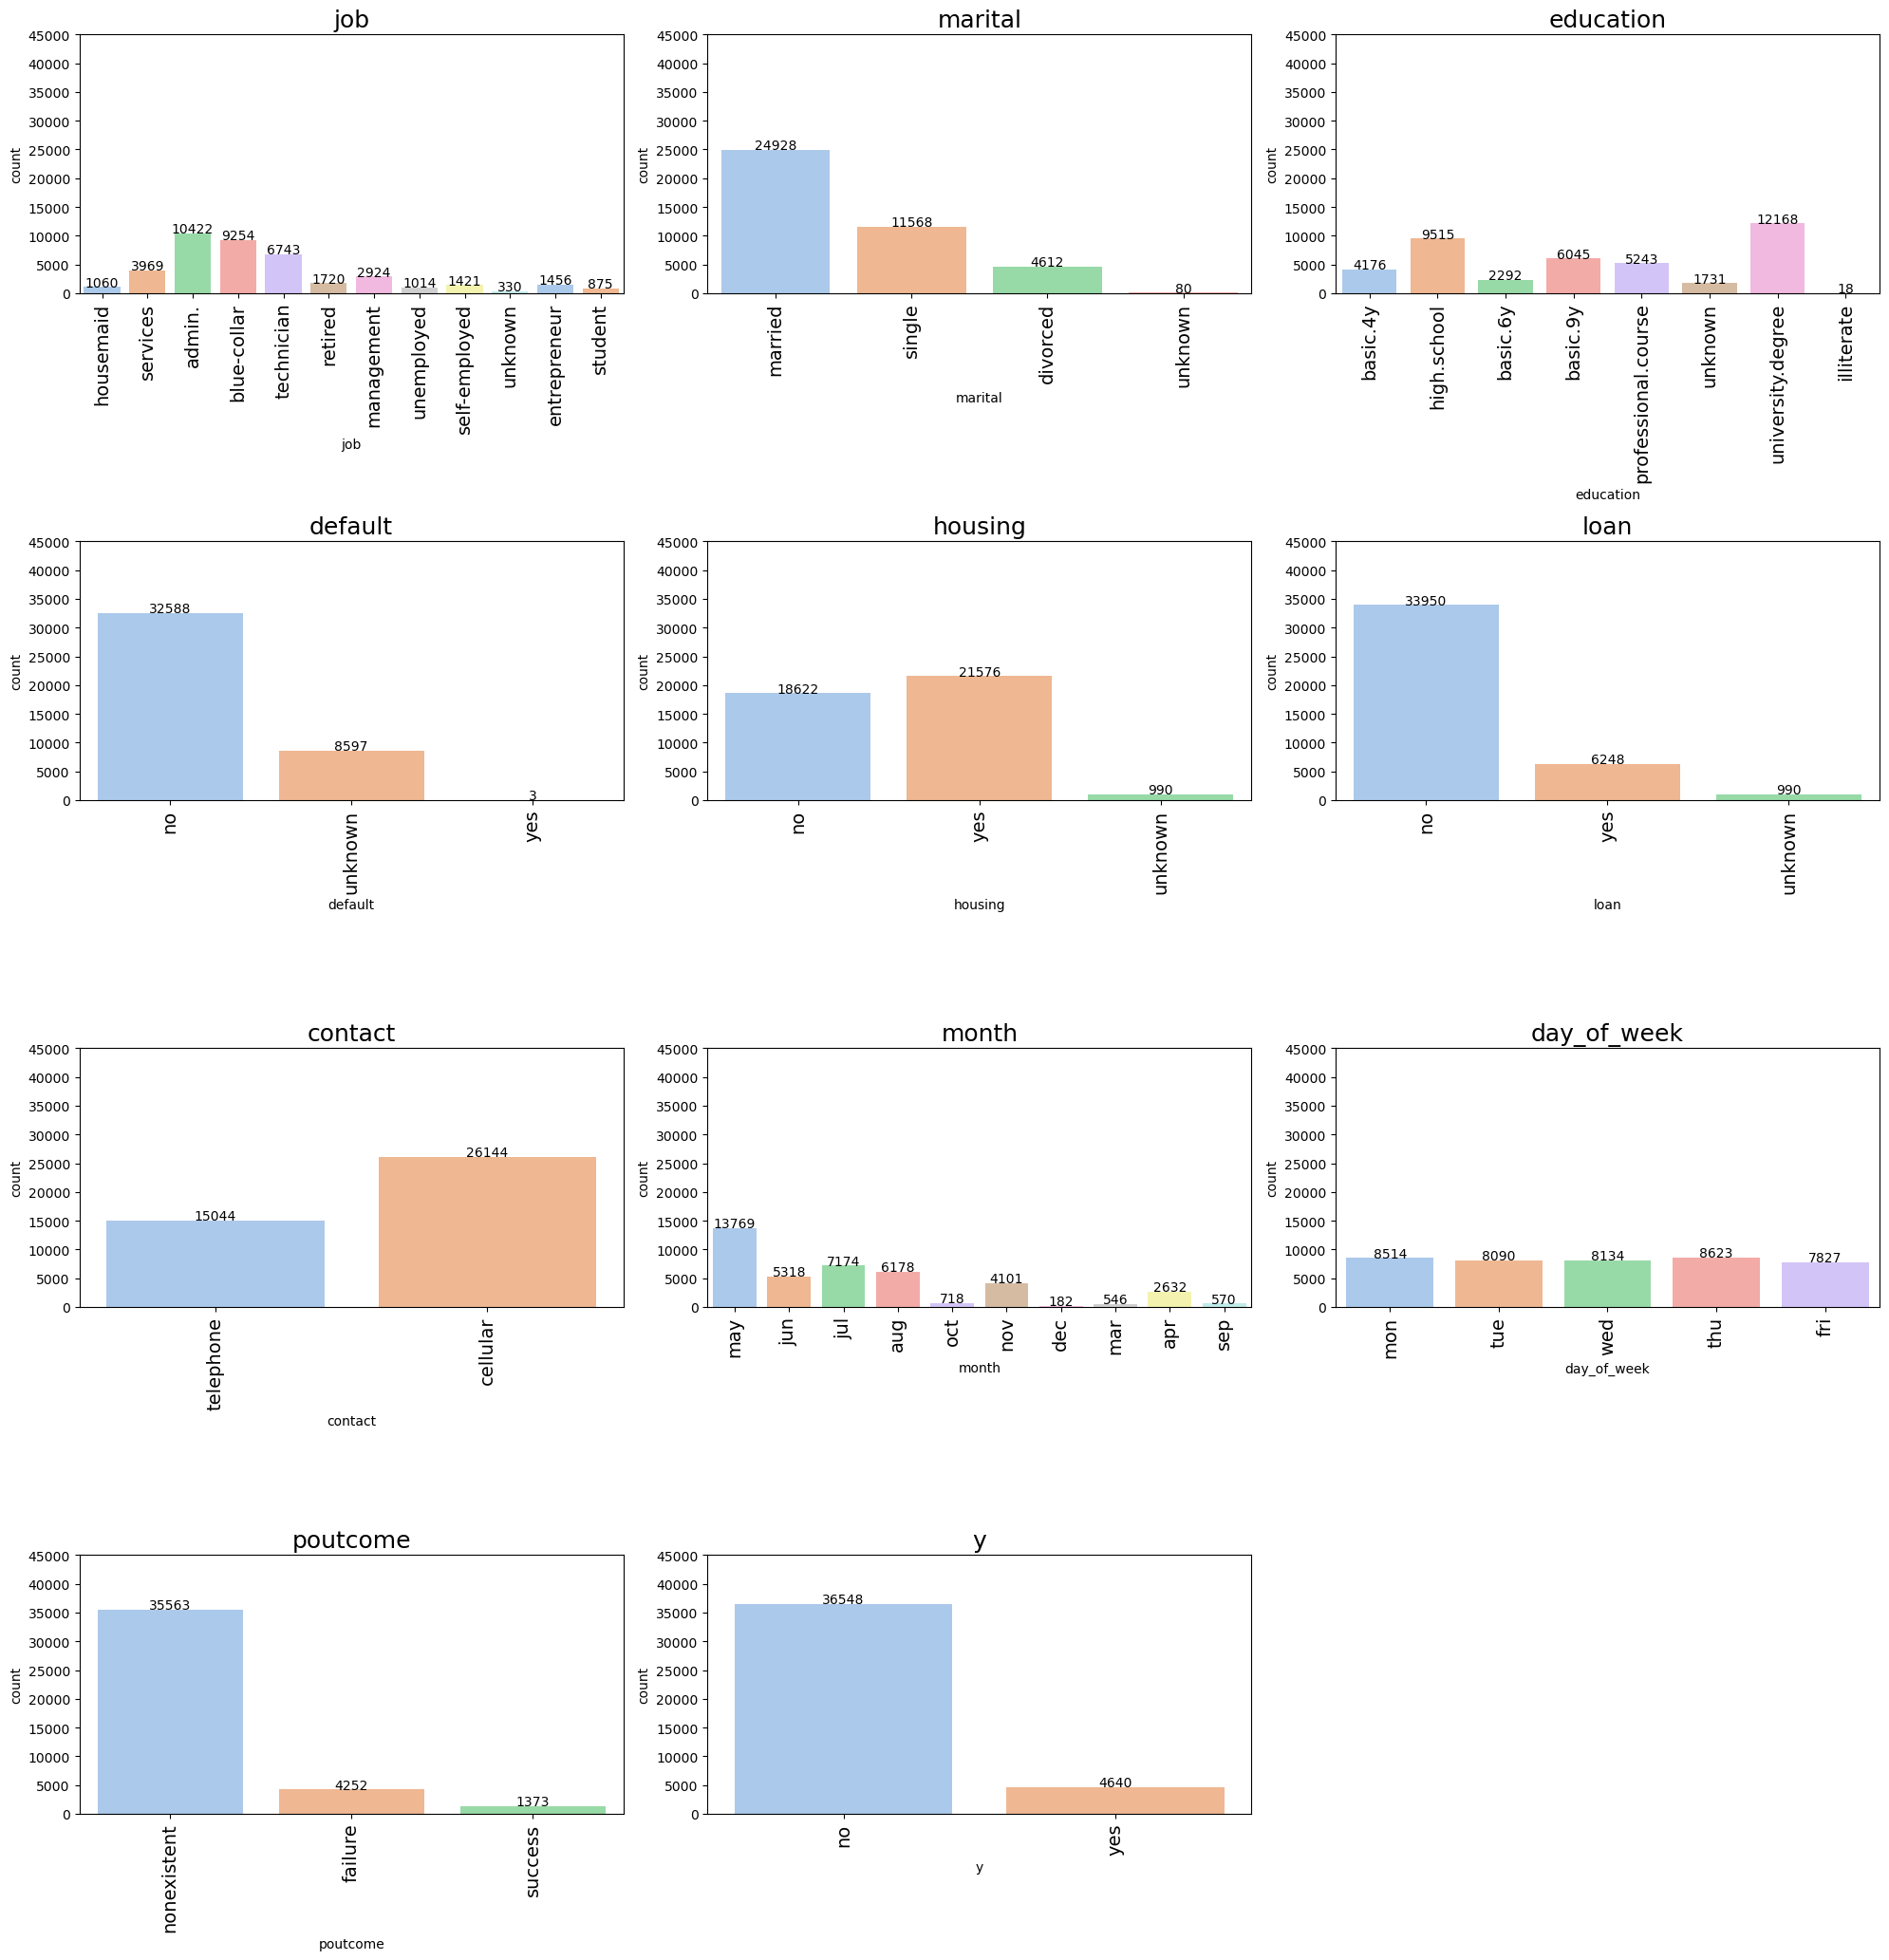

In [47]:
plt.figure(figsize=(20, 30))
plotno = 1
for i in cat_data:
    if plotno <= 17:
        plt.subplot(6, 3, plotno)
        ax = sns.countplot(x=cat_data[i], hue=cat_data[i], palette='pastel', legend=False)
        plt.ylim(0, 10000)
        plt.yticks(range(0, 50000, 5000))
        plt.xticks(rotation=90, fontsize=14)
        plt.title(f"{i}", fontsize=18)

        # Add value labels on top of bars
        for p in ax.patches:
            height = p.get_height()
            if height > 0:  # avoid labeling zero-height bars
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    height + 100,  # slightly above the bar
                    f'{int(height)}',
                    ha='center',
                    fontsize=10,
                    color='black'
                )
        plotno += 1
plt.tight_layout()
plt.show()


**1.job** - 


            0.admin. – Highest in count (10,422); suggests large presence of clerical workers with stable income.
            1.blue-collar – 9,254 entries; major working-class group, may be more interest-rate sensitive.
            2.technician – 6,743 entries; skilled professionals, likely mid-income and analytical.            
            3.services – 3,969 entries; moderate representation, often lower income and customer-facing.            
            4.management – 2,924 entries; fewer but high-value clients, often target for investment products.            
            5.retired – 1,720 entries; fixed-income group, risk-averse and prefers secure savings.
            6.housemaid – 1,060 entries; low-income segment, possibly interested in micro-finance.
            7.self-employed – 1,421 entries; income varies, may need flexible credit products.
            8.entrepreneur – 1,456 entries; niche business owners, potential interest in loans and investments.
            9.unemployed – 1,014 entries; low financial activity, may need basic or recovery products.
            10.student – 875 entries; future customers, likely interested in educational loans and starter accounts.
            11.unknown – 330 entries; missing or invalid job data, may require handling or exclusion.

**2.MARITAL** -

**1.Marital Status:** The marital status chart shows that the majority of the customers in this dataset are married (24,928 individuals). This is a significant demographic that the bank's marketing team should consider when designing campaigns for term deposits.

**2.Single Population:** A considerable portion of the customer base is single (11,568 individuals). This group represents another key segment that might have different financial needs and responses to marketing efforts compared to married individuals. 

**3.Divorced Segment:** The number of divorced individuals (4,612) is smaller than the married and single groups but still represents a notable segment. Their financial circumstances and investment appetites might differ. 

**4.Unknown Marital Status:** The very low number of individuals with unknown marital status (80) suggests that this attribute is largely well-recorded in the dataset. This reduces potential issues related to missing data for this particular feature during analysis and modeling. 

**3.EDUCATION** - 

**1.basic.4y:** This category represents individuals with 4 years of basic education, with a count of 4176. This suggests a segment of the population has completed a primary level of schooling.

**2.high.school:** With 9515 individuals, high school is a more prevalent level of educational attainment in this dataset. A significant   portion of the population has completed secondary education

**3.basic.6y:** This bar indicates 2292 individuals have completed 6 years of basic education. This represents a smaller group compared to those with 4 years or high school education.

**4.basic.9y:** There are 6045 individuals with 9 years of basic education. This suggests a notable number of people have completed lower secondary education.

**5.professional.course:** This category includes 5243 individuals who have completed a professional course. This indicates a segment of the population has pursued vocational or specialized training.

**6.unknown:** The 'unknown' category accounts for 1731 individuals where the level of education is not specified. This missing data point highlights a need for more complete information.

**7.university.degree:** A substantial number, 12168 individuals, hold a university degree. This represents the largest educational attainment group in this dataset.

**8.illiterate:** The bar for 'illiterate' shows a very small count of 18 individuals. This indicates a very low proportion of the population in this dataset is reported as illiterate.              
                

**4.DEFAULT** -

**1. No Credit in Default:** The chart clearly indicates that the vast majority of customers (32,588) have no credit in default. This suggests a relatively low-risk customer base concerning prior credit issues. 

**2. Unknown Default Status:** A notable portion of customers (8,597) have an 'unknown' status regarding their credit in default. This represents a significant amount of missing information for this attribute, which could impact the accuracy of any predictive models.

**3.Few with Credit in Default:** The number of customers with credit in default ('yes') is extremely low (3 individuals). This is a very small segment of the population in this dataset. 

**5.HOUSING** -

**1.no:** This bar represents customers who do not have a housing loan, totaling 18,622 individuals. This suggests a significant portion of the customer base has no current mortgage obligations.

**2.yes:** This bar shows customers who do have a housing loan, with a count of 21,576. This indicates that a slightly larger segment of customers is currently paying off a mortgage.

**3.unknown:** This bar represents customers for whom the housing loan status is unknown, numbering 990 individuals. This missing information will need to be addressed during data analysis and modeling

**6.LOAN** -

**1.no:** This bar represents the majority of customers, 33,950 individuals, who do not have a personal loan. This suggests that most customers are not currently servicing this type of debt.

**2.yes:** This bar shows the number of customers who do have a personal loan, totaling 6,248. This indicates a smaller but still significant portion of the customer base has this financial obligation. 

**3.unknown:** This bar represents customers for whom the personal loan status is unknown, with a count of 990. Similar to other 'unknown' categories, this missing data needs to be addressed in the analysis.

**7.CONTACT** -

**1.telephone:** This bar represents the number of customers who were contacted via telephone, totaling 15,044 individuals. Telephone was one of the communication channels used during the marketing campaigns.

**2.cellular:** This bar shows the number of customers who were contacted via cellular phone, with a count of 26,144. Cellular communication was the more frequently used contact method in these campaigns. 

**7.MONTH** -

**1.may:** May had the highest number of contacts during the campaigns, with 13,769. This suggests May was a significant month for marketing efforts. 

**2.jun:** June recorded 5,318 contacts, a notable decrease from May but still a substantial effort. Marketing activities continued at a lower intensity in June.

**3.jul:** July saw 7,174 contacts, indicating a moderate level of campaign activity. July was another month with a significant number of customer interactions.

**4.aug:** August had 6,178 contacts, similar to July in terms of campaign intensity. August was also a period with considerable marketing outreach

**5.oct:** October shows a significantly lower number of contacts at 718. Marketing activity appears to have been much reduced in October.

**6.nov:** November recorded 4,101 contacts, indicating a moderate level of campaign activity, higher than October. There was a resurgence in marketing efforts in November. 

**7.dec:** December had a very low number of contacts, only 182. Marketing activity was minimal during this month, likely due to the holiday season.

**8.mar:** March shows a very small number of contacts at 546. Marketing efforts were limited in March compared to other months.

**9.apr:** April recorded 2,632 contacts, indicating a moderate level of campaign activity, higher than March and December. Marketing efforts increased in April.

**10.sep:** September had the lowest number of contacts at 570. Marketing activity was minimal in September.


**8.DAY_OF_WEEK** - 

**1.mon:** Monday recorded 8,514 contacts, indicating a strong start to the week for marketing activities. Monday was a significant day for customer outreach.

**2.tue:** Tuesday saw 8,090 contacts, a slightly lower number than Monday but still a substantial effort. Marketing campaigns continued actively on Tuesday.

**3.wed:** Wednesday had 8,134 contacts, similar to Tuesday in terms of campaign intensity. Wednesday was another day with considerable customer interaction. 

**4.thu:** Thursday recorded the highest number of contacts during the week at 8,623. Thursday appears to have been the most active day for marketing calls.

**5.fri:** Friday saw 7,827 contacts, the lowest number among the weekdays. Marketing activity appears to have tapered off towards the end of the working week.

**9.POUTCOME** -

**1.nonexistent:** This bar represents the majority of customers (35,563) for whom there was no previous marketing campaign. This indicates that most customers were contacted for the first time during the current campaign.

**2.failure:** This bar shows customers (4,252) for whom the previous marketing campaign resulted in a failure. These customers had been contacted before but did not subscribe to a term deposit in the past.

**3.success:** This bar represents customers (1,373) for whom the previous marketing campaign was a success. These customers had subscribed to a term deposit during a prior campaign.

**10.Y** -

**1.no:** This bar represents the number of customers who did not subscribe to a term deposit, totaling 36,548. This is the majority outcome of the marketing campaigns in this dataset.

**2.yes:** This bar shows the number of customers who did subscribe to a term deposit, with a count of 4,640. This is the positive outcome that the bank's marketing team aims to increase.

### UNIVARIATE ANALYSIS FOR NUMERICAL DATA

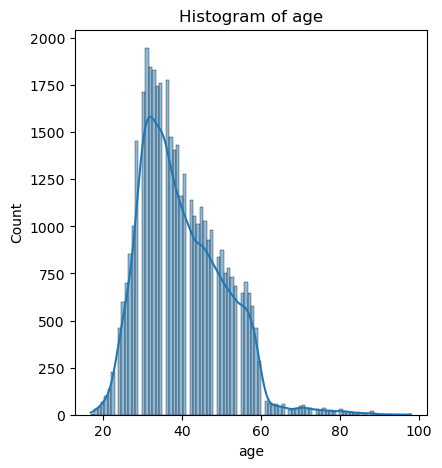

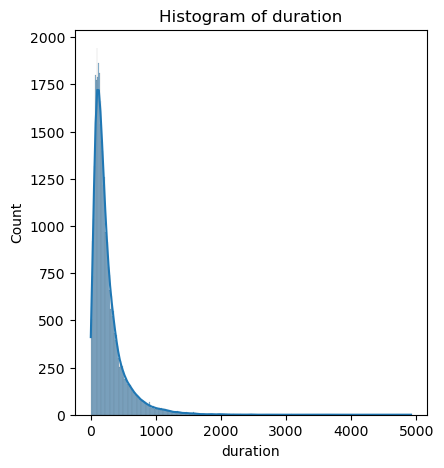

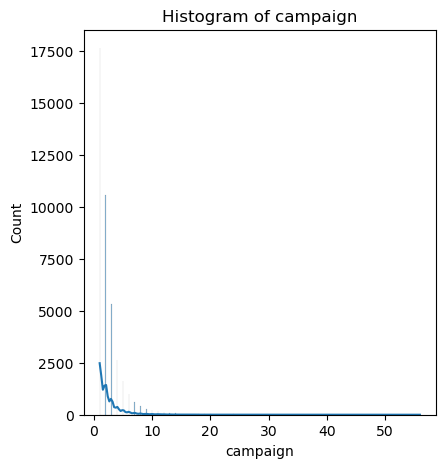

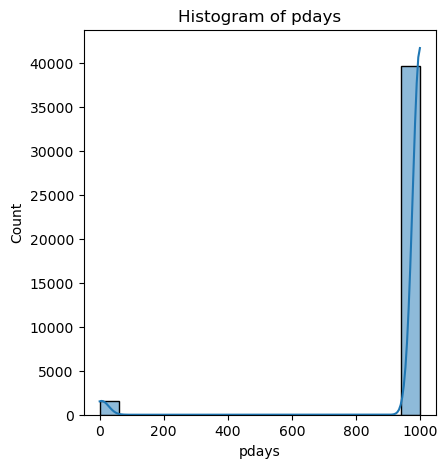

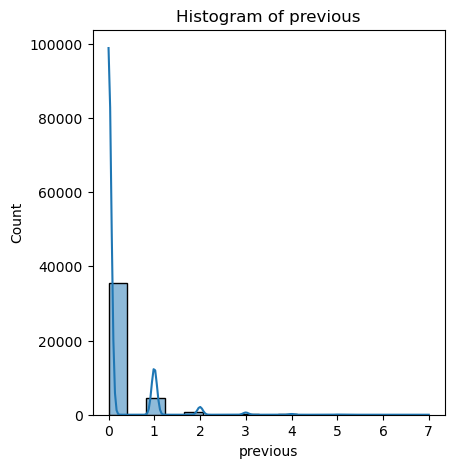

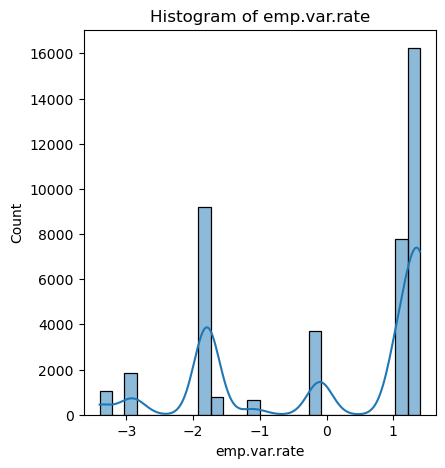

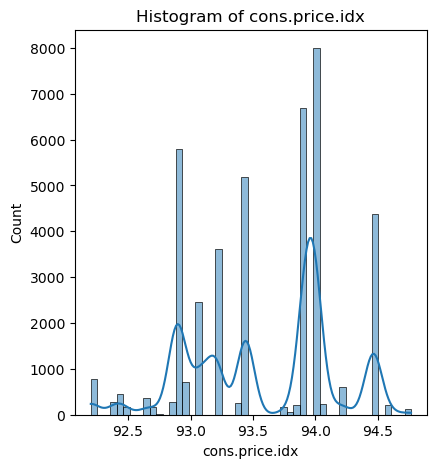

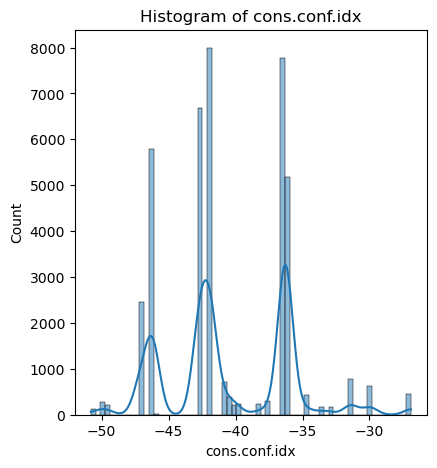

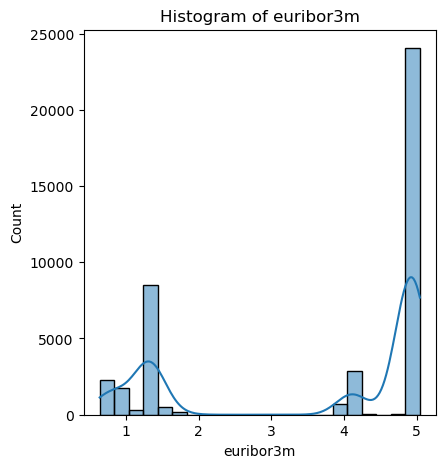

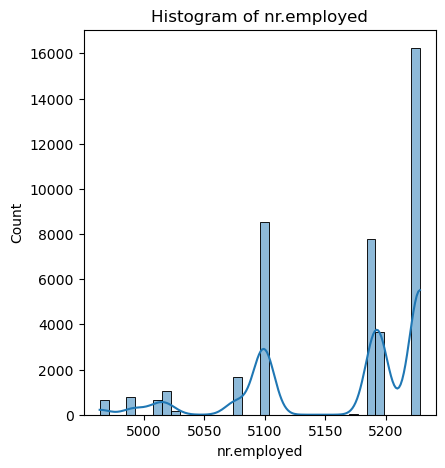

In [60]:
for col in num_data:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.show()

**1.Age** - 

-> Positively skewed (right-skewed), meaning most people are younger, and fewer are older.

->Around 30 to 40 years has the highest frequency

->The most frequent age group reaches just under 2000 individuals.

-> A long tail stretches towards older ages (above 60), with very few people above 80.
            

**2.Duration** -

-> Highly right-skewed (positively skewed).

->Concentrated around 0 to 300 seconds.

-> Just under 2000 entries at the lower end of duration.

-> A few values go all the way up to ~5000 seconds, but they are rare.

->Sharp drop in frequency as the duration increases.

**3.campagin** -

->  Extremely right-skewed distribution.

-> 1 to 3 contact attempts are the most frequent.

-> The majority of entries fall within 0 to 5

->Frequency decreases drastically after 5.

**4.pdays** -

->Two dominant spikes:One at 999 (far right) & One at 0 (far left).

->his usually means the client was not previously contacted.

**5.previous** -

->Very right-skewed distribution.

->Majority of values are at 0, followed by a rapid decline for 1, 2, etc.

->Most clients were never contacted before the current campaign.

**6.emp.var.rate** - 

->The histogram shows multiple distinct peaks, indicating that the variable has a multimodal distribution. This suggests that the data may come from different time periods or groups with varying economic conditions.

->he highest peak is around 1.1, with over 16,000 occurrences. This suggests that during most observations, the employment variation rate was relatively high and positive.

->There's a noticeable peak around -1.8 and -3.4, which suggests that the dataset also includes periods of economic downturn or negative employment variation.

**7.cons.price.idx** -

->The consumer price index (cons.price.idx) mostly lies between 92 and 95, indicating that this variable is relatively stable and doesn’t fluctuate widely in this dataset.

**8.cons.conf.idx** -

->The consumer confidence index values are entirely in the negative range, mostly between -50 and -30. This indicates generally pessimistic sentiment among consumers during the period covered.

->The KDE curve shows multiple peaks, indicating a multimodal distribution. This suggests that consumer confidence varied significantly over time, possibly due to economic events or policy shifts.

->Although all values are negative, there's a subtle skew toward the right (less negative values), implying that during some periods, consumer sentiment was closer to neutral than others.

**9.euribor3m** -

->The distribution shows two clear peaks: one near 1.25 and another around 4.95, suggesting that the data captures two distinct economic periods — one with low interest rates and another with much higher rates.

->he highest bar is at ~4.95 with over 24,000 observations, indicating that this interest rate level was very common during the observed period.

**10.nr.employed** -

->The histogram clearly shows multiple peaks, indicating that the number of employees has varied in distinct clusters over time — possibly reflecting economic cycles or seasonal employment changes.

->The most frequent value is approximately 5220, with over 16,000 occurrences. This suggests that a large portion of the data was recorded during a time of relatively high employment.

->A significant number of observations also fall in the 5000–5100 range, suggesting a past period of lower employment, possibly due to economic downturns or recessions.

# BIVARIATE ANALYSIS

#### BIVARIATE ANALYSIS FOR CATEGORICAL DATA

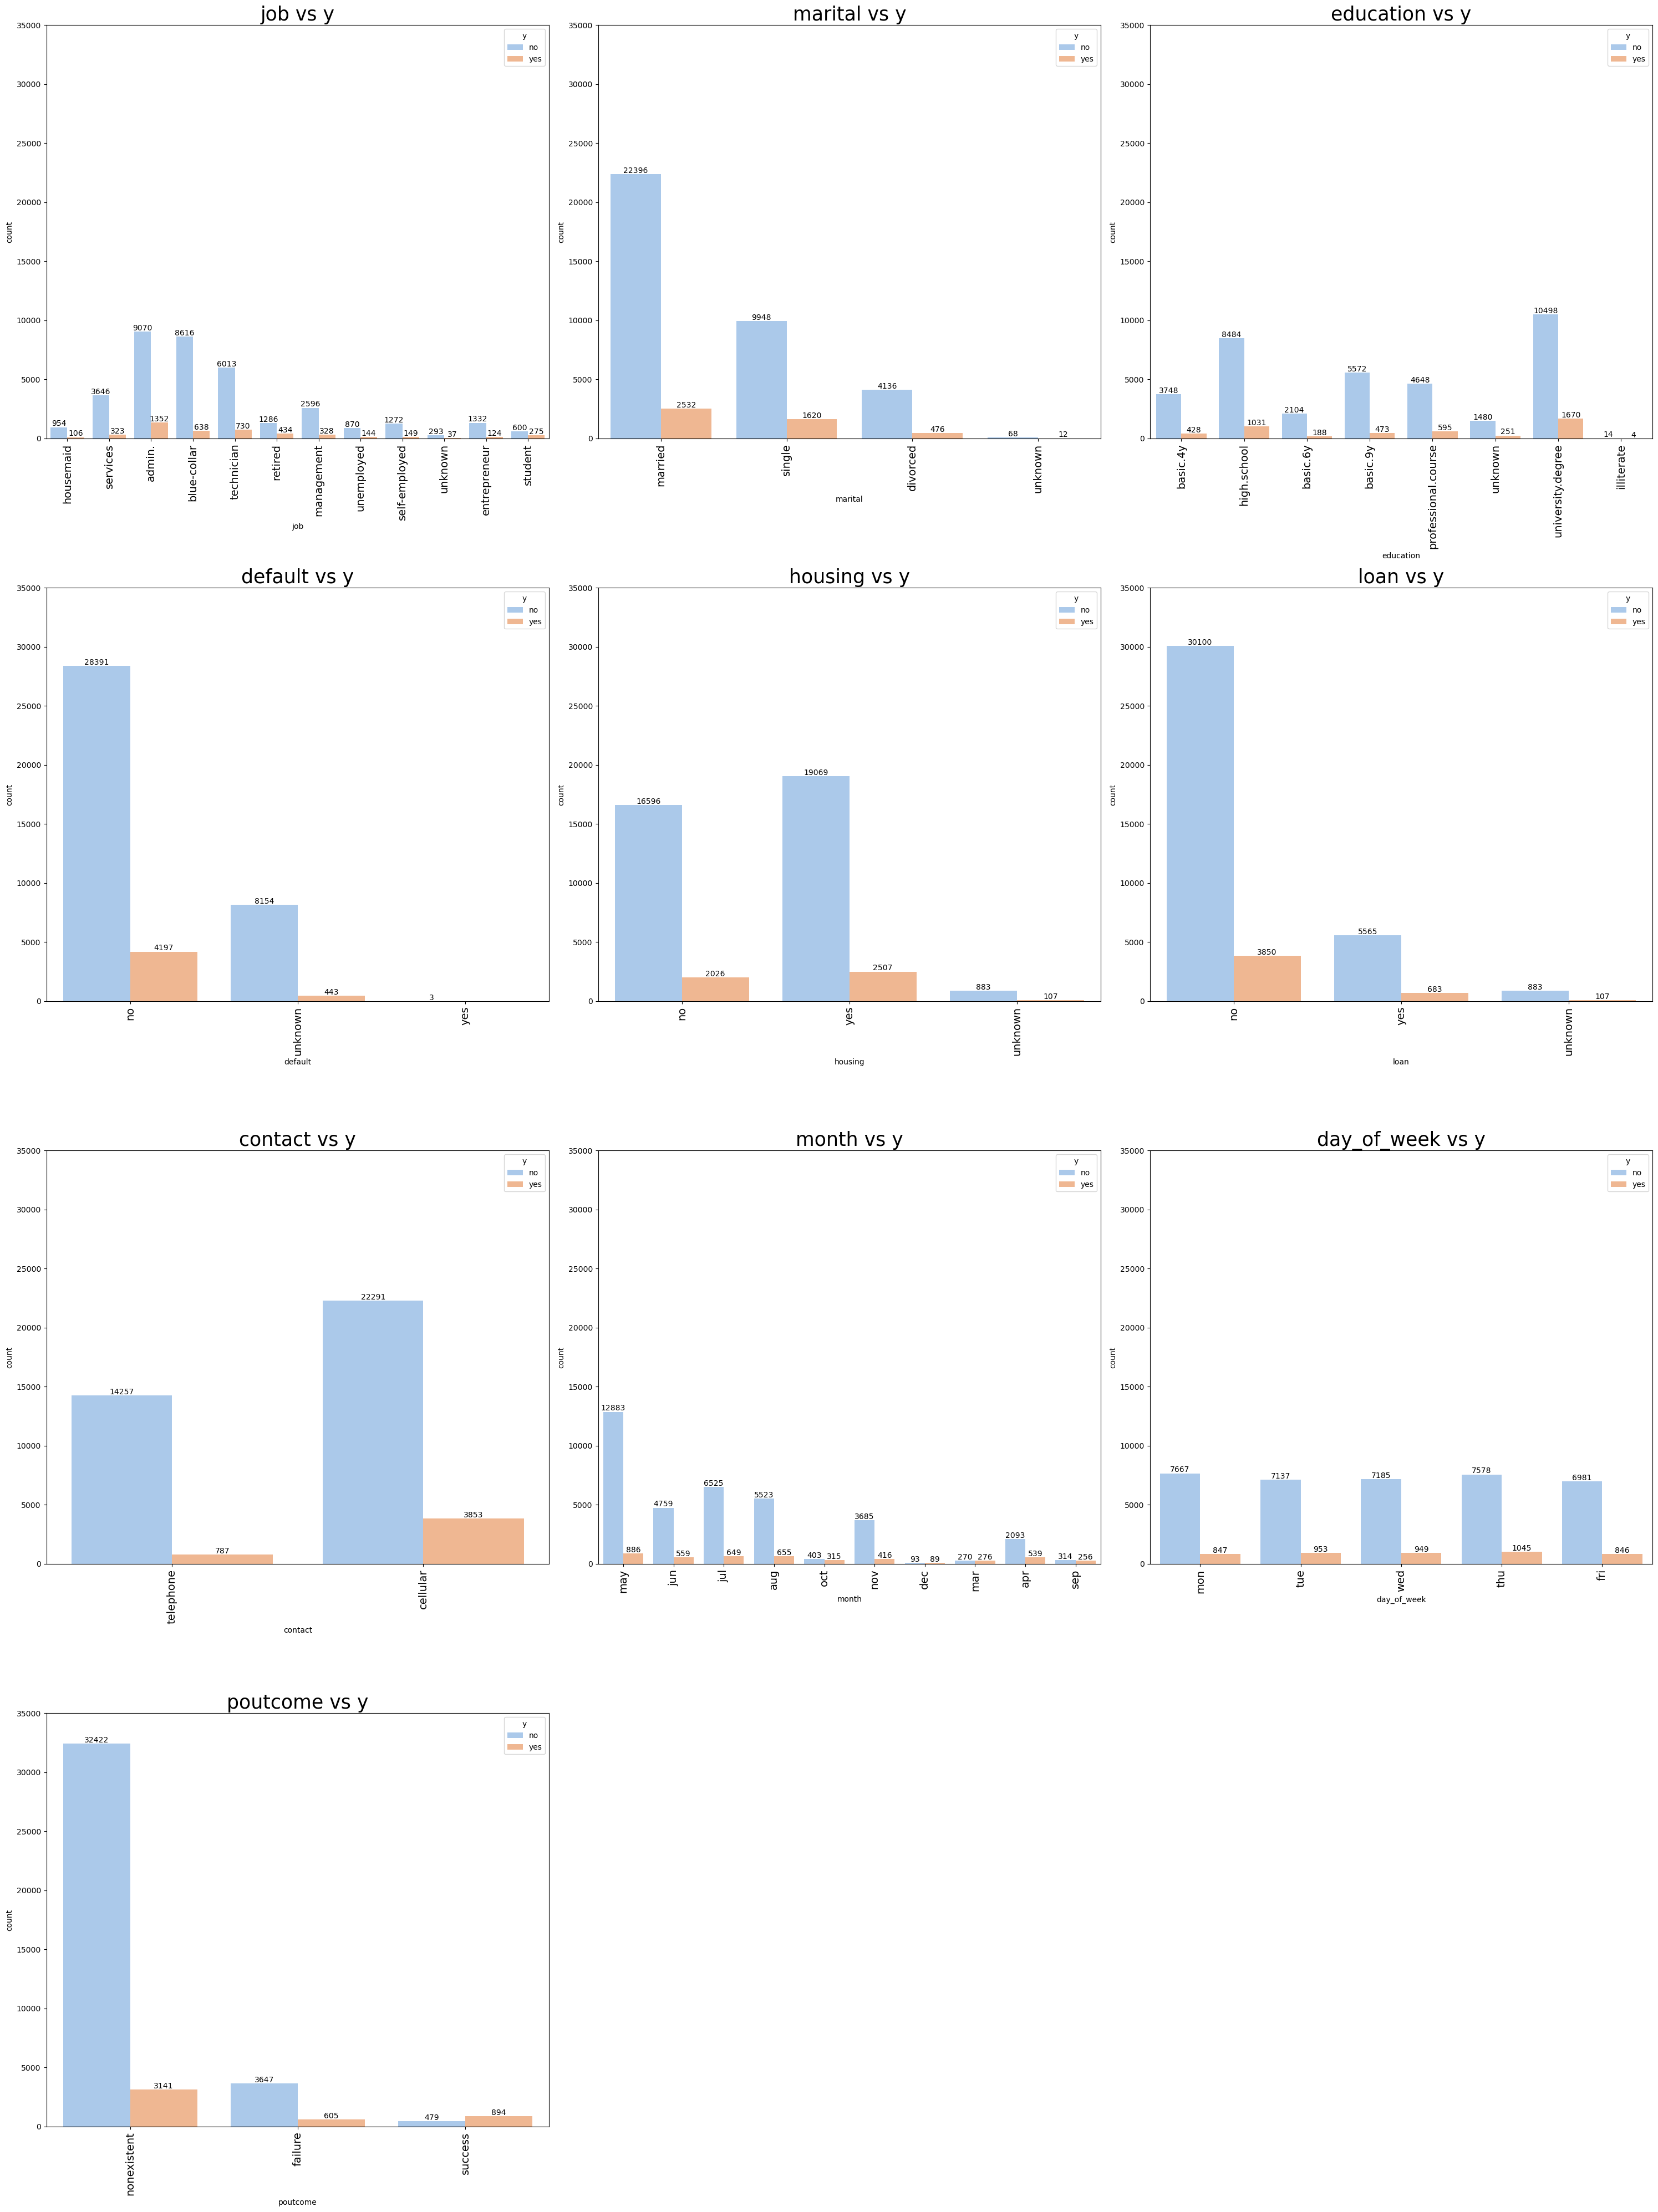

In [73]:
plt.figure(figsize=(30, 40))
plotno = 1
target = 'y'  # Replace this with your actual target variable if it's different

for i in cat_data.columns:
    if i != target and plotno <= 17:
        plt.subplot(4, 3, plotno)
        ax = sns.countplot(x=cat_data[i], hue=cat_data[target], palette='pastel')
        plt.ylim(0, 10000)
        plt.yticks(range(0, 40000, 5000))
        plt.xticks(rotation=90, fontsize=14)
        plt.title(f"{i} vs {target}", fontsize=25)

        # Add value labels on top of bars
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    height + 100,
                    f'{int(height)}',
                    ha='center',
                    fontsize=10,
                    color='black'
                )
        plotno += 1

plt.tight_layout()
plt.show()


**1.job vs y** -

->Admin and blue-collar professions have the highest number of clients overall.

->Although the student and retired categories have lower total counts, they show a higher proportion of 'yes' compared to others.

->Housemaid and Services Show Low EngagementThese groups have very few "yes" responses relative to "no", suggesting lower interest or response rates.

->Technician and Management Are Balanced Segments,These job types show moderate numbers with a mix of both "yes" and "no", making them potential targets for optimized marketing strategies.

->Entrepreneurs and Self-Employed Have Low Participation the counts are relatively low for entrepreneurs and self-employed, and they also show low "yes" response rates, possibly due to time constraints or risk aversion.

**2.marital vs y** -

->he married group has the highest number of clients (~22,396 "no" and 2,532 "yes"), indicating it is the largest segment.

->Although fewer in total count than married clients, single individuals show a better conversion rate, suggesting they may be more open or flexible to offers.

->The divorced category, while smaller, still shows a reasonable number of "yes" responses, suggesting some potential for targeting.

->The unknown group is tiny and unlikely to influence overall results; it may be safe to exclude or impute during modeling.

->Campaigns might perform better if focused on single and divorced individuals, as they seem more responsive relative to their group size than married ones.

**3.education vs y** -

->The university degree group has the highest number of clients overall, but also a relatively low "yes" rate, suggesting that education level alone does not guarantee interest.

->Clients who took professional courses have a higher proportion of "yes" responses relative to their group size, indicating this segment could be more open to offers.

->Across the basic education categories, the number of "yes" responses is significantly low. This could reflect less financial flexibility, lower product fit, or trust issues.

->The high school group has a decent "yes" count (1,031) and could be seen as a middle ground in terms of responsiveness.

->The "unknown" group might benefit from data cleaning or imputation, while "illiterate" can be excluded due to its very small size.

**4.default vs y** -

->Most Clients Have No Credit Default the "no" category dominates, with 28,391 "no" responses and 4,137 "yes", indicating the majority of clients do not have credit in default.

->Defaulted Clients Rarely Respond Positively the "yes" group (clients with credit default) has only 3 total clients with 0 positive ("yes") responses, suggesting they are extremely unlikely to accept campaign offers.

->"Unknown" Credit Default Status Is a Concern A significant number of clients (8,154) fall into the "unknown" category, with only 443 "yes" responses.

->This uncertainty might hinder targeting accuracy and could benefit from data clarification or imputation.

->Clients with no default show a good number of "yes" responses (4,137), indicating that creditworthy individuals are more receptive.

->Campaigns should focus on clients with no default, and potentially exclude or deprioritize those with default or unknown credit history unless more information becomes available.

**5.housing vs y** -

->Clients With Housing Loans Are More Numerous The "yes" group (with housing loan) has the highest total count, indicating many clients in the dataset have active housing loans.

->Clients Without Housing Loans Show Slightly Better Conversion While fewer in number, the "no" group has fewer total clients but nearly the same number of "yes" responses as the "yes" group — suggesting that clients without housing loans are slightly more responsive.

->Even though clients with housing loans may have financial commitments, they still show a respectable number of positive responses (2,307), meaning they're still viable targets.

->The "unknown" group is relatively small (only 893 "no" and 107 "yes"), but should be reviewed for potential data cleaning or imputation to improve model accuracy.

->Campaigns can target both "no" and "yes" clients, but perhaps slightly prioritize those without housing loans, as they may have more financial flexibility or interest.

**6.loan vs y** -

->A large number of individuals without loans (around 30,100) did not subscribe to the product (y = no), compared to a smaller portion (around 2,850) who did (y = yes).

->People With Loans Are Less Likely to Subscribe , mong those who have loans, the number who subscribed (y = yes, around 653) is significantly lower than those who didn't (y = no, around 5,965).

->In all loan categories (no, yes, unknown), the count of y = yes is substantially lower than y = no, indicating a generally low subscription rate.

->The ‘unknown’ category has the fewest entries, with only about 803 non-subscribers and 107 subscribers, which might suggest missing or incomplete data.

->People without loans are more likely to subscribe than those with loans, implying that loan status could influence financial decisions like subscribing to a product.

**7.contact vs y** -

->More people subscribed (y = yes) when contacted via cellular (3853) compared to telephone (787), indicating better results with cellular contact.

-> Although a significant number of people were contacted by telephone (14,257), only a small fraction subscribed, showing a lower success rate.

->Cellular is the more frequently used contact method (2,291) compared to telephone, suggesting a shift or preference towards mobile outreach.

->The method of contact clearly influences the likelihood of subscription, with cellular contact being more effective in driving conversions.

**8.month vs y** -

->While May saw the most contacts (≈12,883), the number of successful subscriptions (y = yes, 886) is low in proportion, suggesting inefficiency.

->August shows a relatively high success rate, with 655 subscriptions out of 5,523 contacts—better proportionally than May or June.

->October (315 yes out of 4,651) and March (276 yes out of 270) seem to have higher conversion efficiency, possibly due to targeted campaigns or timing.

->These months have very few contacts and subscriptions, indicating minimal campaign activity during the winter season.

**9.day_of_week vs y** -

->While May saw the most contacts (12,883), the number of successful subscriptions (y = yes,86) is low in proportion, suggesting inefficiency.

->August shows a relatively high success rate, with 655 subscriptions out of 5,523 contacts—better proportionally than May or June.

->October (315 yes out of 4,651) and March (276 yes out of 270) seem to have higher conversion efficiency, possibly due to targeted campaigns or timing.

**10.poutcome vs y** -

->Thursday has the highest number of subscriptions (y = yes,1,045), suggesting it's the most effective day for contacting potential subscribers.

->Tuesday follows closely with 953 successful subscriptions, indicating good campaign engagement early in the week.

->Both contact volume (6,931) and successful subscriptions (846) are the lowest on Friday, possibly due to end-of-week disengagement.

->The number of people contacted each weekday is relatively consistent (7,000–7,600), showing an even campaign distribution.

#### BIVARIATE ANALYSIS FOR NUMERICAL DATA

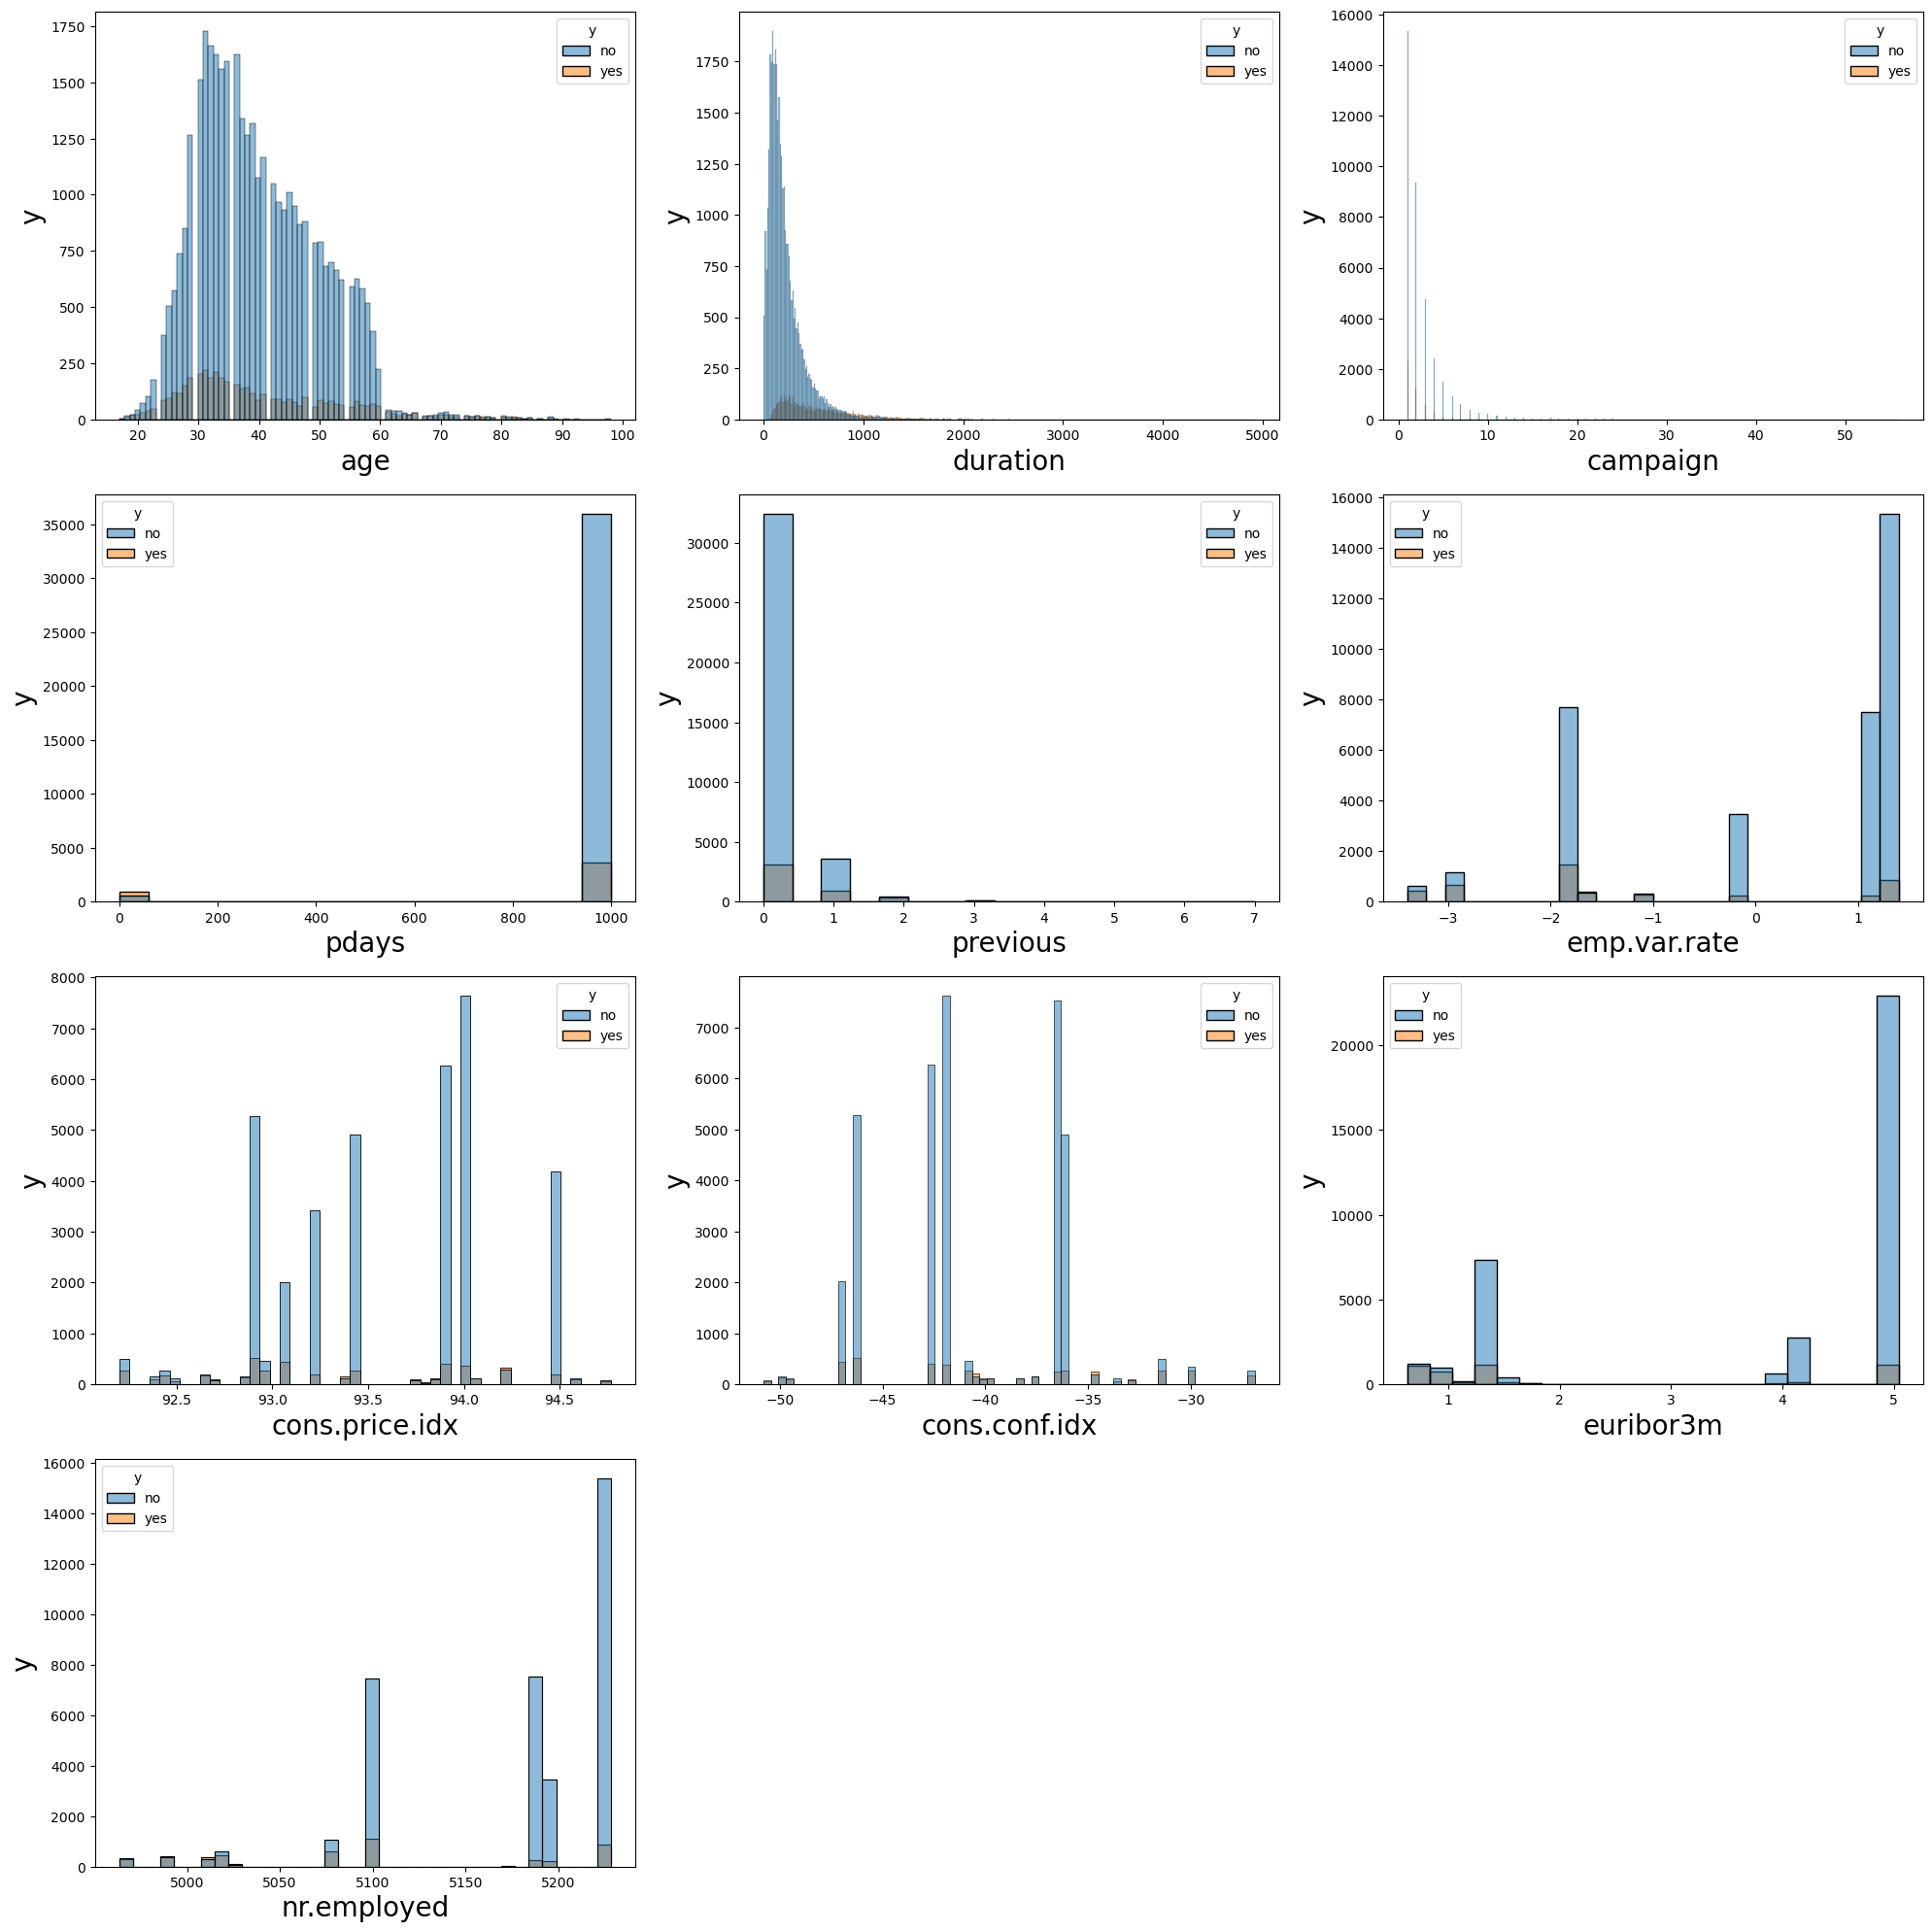

In [85]:
plt.figure(figsize=(20,20),facecolor='white')
plotnumber=1
for column in num_data:
    if plotnumber<=12:
        ax = plt.subplot(4,3,plotnumber)
        sns.histplot(x=num_data[column],hue=data['y'])
        plt.xlabel(column,fontsize=20)
        plt.ylabel('y',fontsize=20)
    plotnumber+=1
plt.tight_layout()

**1.age** - 

            ->Although older age groups (40–60) are fewer, a larger proportion of them say "yes" to the marketing campaign.

            ->This suggests older clients might be more receptive or financially capable of accepting the offer.

            ->people in their early 20s are less likely to respond positively ("yes").

            ->This could indicate less interest or financial readiness among younger individuals.

            ->While volume is low, conversion ratio is high in the 45–60 range

            ->This suggests a good opportunity to re-target or personalize marketing for that age group.




**2.duration** -

             ->The vast majority of calls are under 500 seconds (8 minutes)

             ->The number of "yes" responses increases with longer calls.

             ->Especially after 300 seconds, there's a noticeable shift—fewer people say "no" while "yes" remains.

             ->This implies: the longer the call, the higher the chance of success.

             ->When call duration is under 100 seconds, almost all outcomes are "no".


**3.campagin** - 

              -> Clients who responded "yes" were typically contacted fewer times, mostly 1–5 times.

              ->This implies early contact is more effective, and repeated calls may reduce success.

              ->For clients who were contacted 10+ times, almost all outcomes are "no".

              ->Repeated attempts (especially 20+ calls) are heavily skewed toward negative outcomes.

              ->Clients who convert are generally engaged quickly, without the need for multiple reminders.

              ->Indicates that a good initial pitch and targeting are crucial.

**4.pdays** -

            ->A huge spike at 999 indicates that the majority of clients have never been contacted before.

            ->Among those with pdays = 999, very few subscribed (y = yes). The blue bar (no) dominates the orange (yes).

            ->Clients who were recently contacted (lower pdays values) show a higher proportion of yes responses.

            ->This implies follow-up calls can increase conversion rates.

            ->Distribution is heavily right-skewed due to the large number of 999 values.

            

**5.previous** -

            ->The vast majority of clients (over 30,000) had previous = 0,meaning they had no prior contact before the current campaign.

            ->Clients with previous > 0 (i.e.,they had been contacted before) appear to have a higher proportion of "yes" responses.
              While fewer in number,these clients show a more balanced bar between "yes" and "no",indicating higher effectiveness of
              repeated contact.

            ->As the number of previous contacts increases from 1 to 2, there is a noticeable, though still limited, increase in the
              relative share of "yes" outcomes.

            ->or previous values higher than 2, the number of clients drops sharply. This may indicate that repeatedly contacting the
              same clients yields diminishing returns or is less common in practice.

            ->The data is heavily skewed towards clients with previous = 0, which suggests that most marketing efforts are first-time
              contacts.

**6.emp.var.rate** -

            ->The majority of clients fall under emp.var.rate = 1, with a very high number of "no" responses.
            
            ->While "yes" responses exist here, they are a small fraction, indicating that even in seemingly favorable employment
              conditions, the campaign wasn't very successful.
              
            ->Even though the total number of clients is smaller at negative employment variation rates (economic downturns), the
              proportion of "yes" outcomes is higher compared to higher rates.This suggests clients might be more receptive during
              economic uncertainty.

            ->There is minimal client response (in total volume and "yes" count) at these rates. It might indicate either
              under-targeting or lower effectiveness during economic stagnation.  

  

**7.cons.price.idx**-

             ->The highest number of client contacts happened when the consumer price index was around 94.0, especially at values like
               94.0 and 93.9, with a heavy dominance of "no" outcomes.

             ->While less frequent, lower CPI values (e.g., 92.5 – 93.0) show a relatively higher proportion of "yes" outcomes compared
               to the total contacts. This might suggest that consumers are more responsive during periods of lower consumer prices.

             ->In this mid-range zone, there's a noticeable increase in the share of "yes" responses even though total contacts are
                lower. This could be a potential sweet spot for campaign effectiveness. 

                

   


**8.cons.conf.idx** -

            ->A significant portion of contacts were made when cons.conf.idx was around -46 to -36, indicating that most campaign
              efforts occurred during periods of low consumer confidence.

            ->Despite low overall optimism (e.g., cons.conf.idx ≈ -45 to -40), there are still notable "yes" responses.

            ->As the cons.conf.idx increases (closer to -30), the number of contacts drops, and there is no clear spike in "yes"
              outcomes, indicating no strong positive correlation between confidence and campaign success.

            ->Peak Contact at cons.conf.idx ≈ -41 to -36 This range shows the highest number of total contacts, but similar to previous
              plots, the proportion of "yes" outcomes is relatively low, suggesting potential over-targeting or campaign fatigue in
              that range.

**9.euribor3m** -

            ->The majority of clients were contacted when the interest rate was around 5.0. However, the conversion rate ("yes") is very
              low at this level despite the high number of contacts.

            ->When the Euribor rate was between 1.0 and 1.5, the proportion of "yes" outcomes was noticeably higher, even though the
              total number of contacts was lower—this suggests better effectiveness during lower interest rate periods.

            ->There is a clear gap in data between 2.5 and 3.5, which could suggest fewer economic fluctuations at those levels or
               campaign inactivity. It's a missed opportunity for a balanced analysis.

            ->The spike in contacts at euribor3m = 5.0 has a low "yes" proportion, indicating that high borrowing costs may negatively
              affect consumer sentiment and reduce campaign success.  

  

**10.nr.employed** -

            ->The largest group of contacts was made when nr.employed ≈ 5220, but most responses were "no", indicating limited
              effectiveness of the campaign during high employment periods.

            ->When nr.employed was around 5090 to 5100, there was a better balance of "yes" to "no" responses, suggesting that campaigns
              were more successful during periods of lower employment.

           

  

# DATA PREPROCESSING

#### CHECKING NULL VALUES

In [98]:
data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

**Their is no missing data or null values**

### Assigning the unknown values with high frequency values

In [101]:
data['job'] = data.loc[:,'job'].replace({'unknown':'admin.'})
data['marital'] = data.loc[:,'marital'].replace({'unknown':'married'})
data['education'] = data.loc[:,'education'].replace({'unknown':'university.degree'})
data['default'] = data.loc[:,'default'].replace({'unknown':'no'})
data['housing'] = data.loc[:,'housing'].replace({'unknown':'yes'})
data['loan'] = data.loc[:,'loan'].replace({'unknown':'no'})

#### Handle placeholder value in 'pdays' (999 means never contacted)

In the 'pdays' column, 999 indicates that the client was never contacted before. Since 0 is also being used to represent "never contacted before," we are replacing 999 with 0

In [104]:
data.pdays.value_counts()

pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64

In [105]:
data['pdays'] = data['pdays'].replace(999, 0)


In [106]:
data.pdays.value_counts()

pdays
0     39688
3       439
6       412
4       118
9        64
2        61
7        60
12       58
10       52
5        46
13       36
11       28
1        26
15       24
14       20
8        18
16       11
17        8
18        7
22        3
19        3
21        2
25        1
26        1
27        1
20        1
Name: count, dtype: int64

## CHECKING OUTLINERS AND IMPUTE OUTLINERS

BoxPlot: Box plots are used to show distributions of numeric data values as well as it helps to detect the outliers.

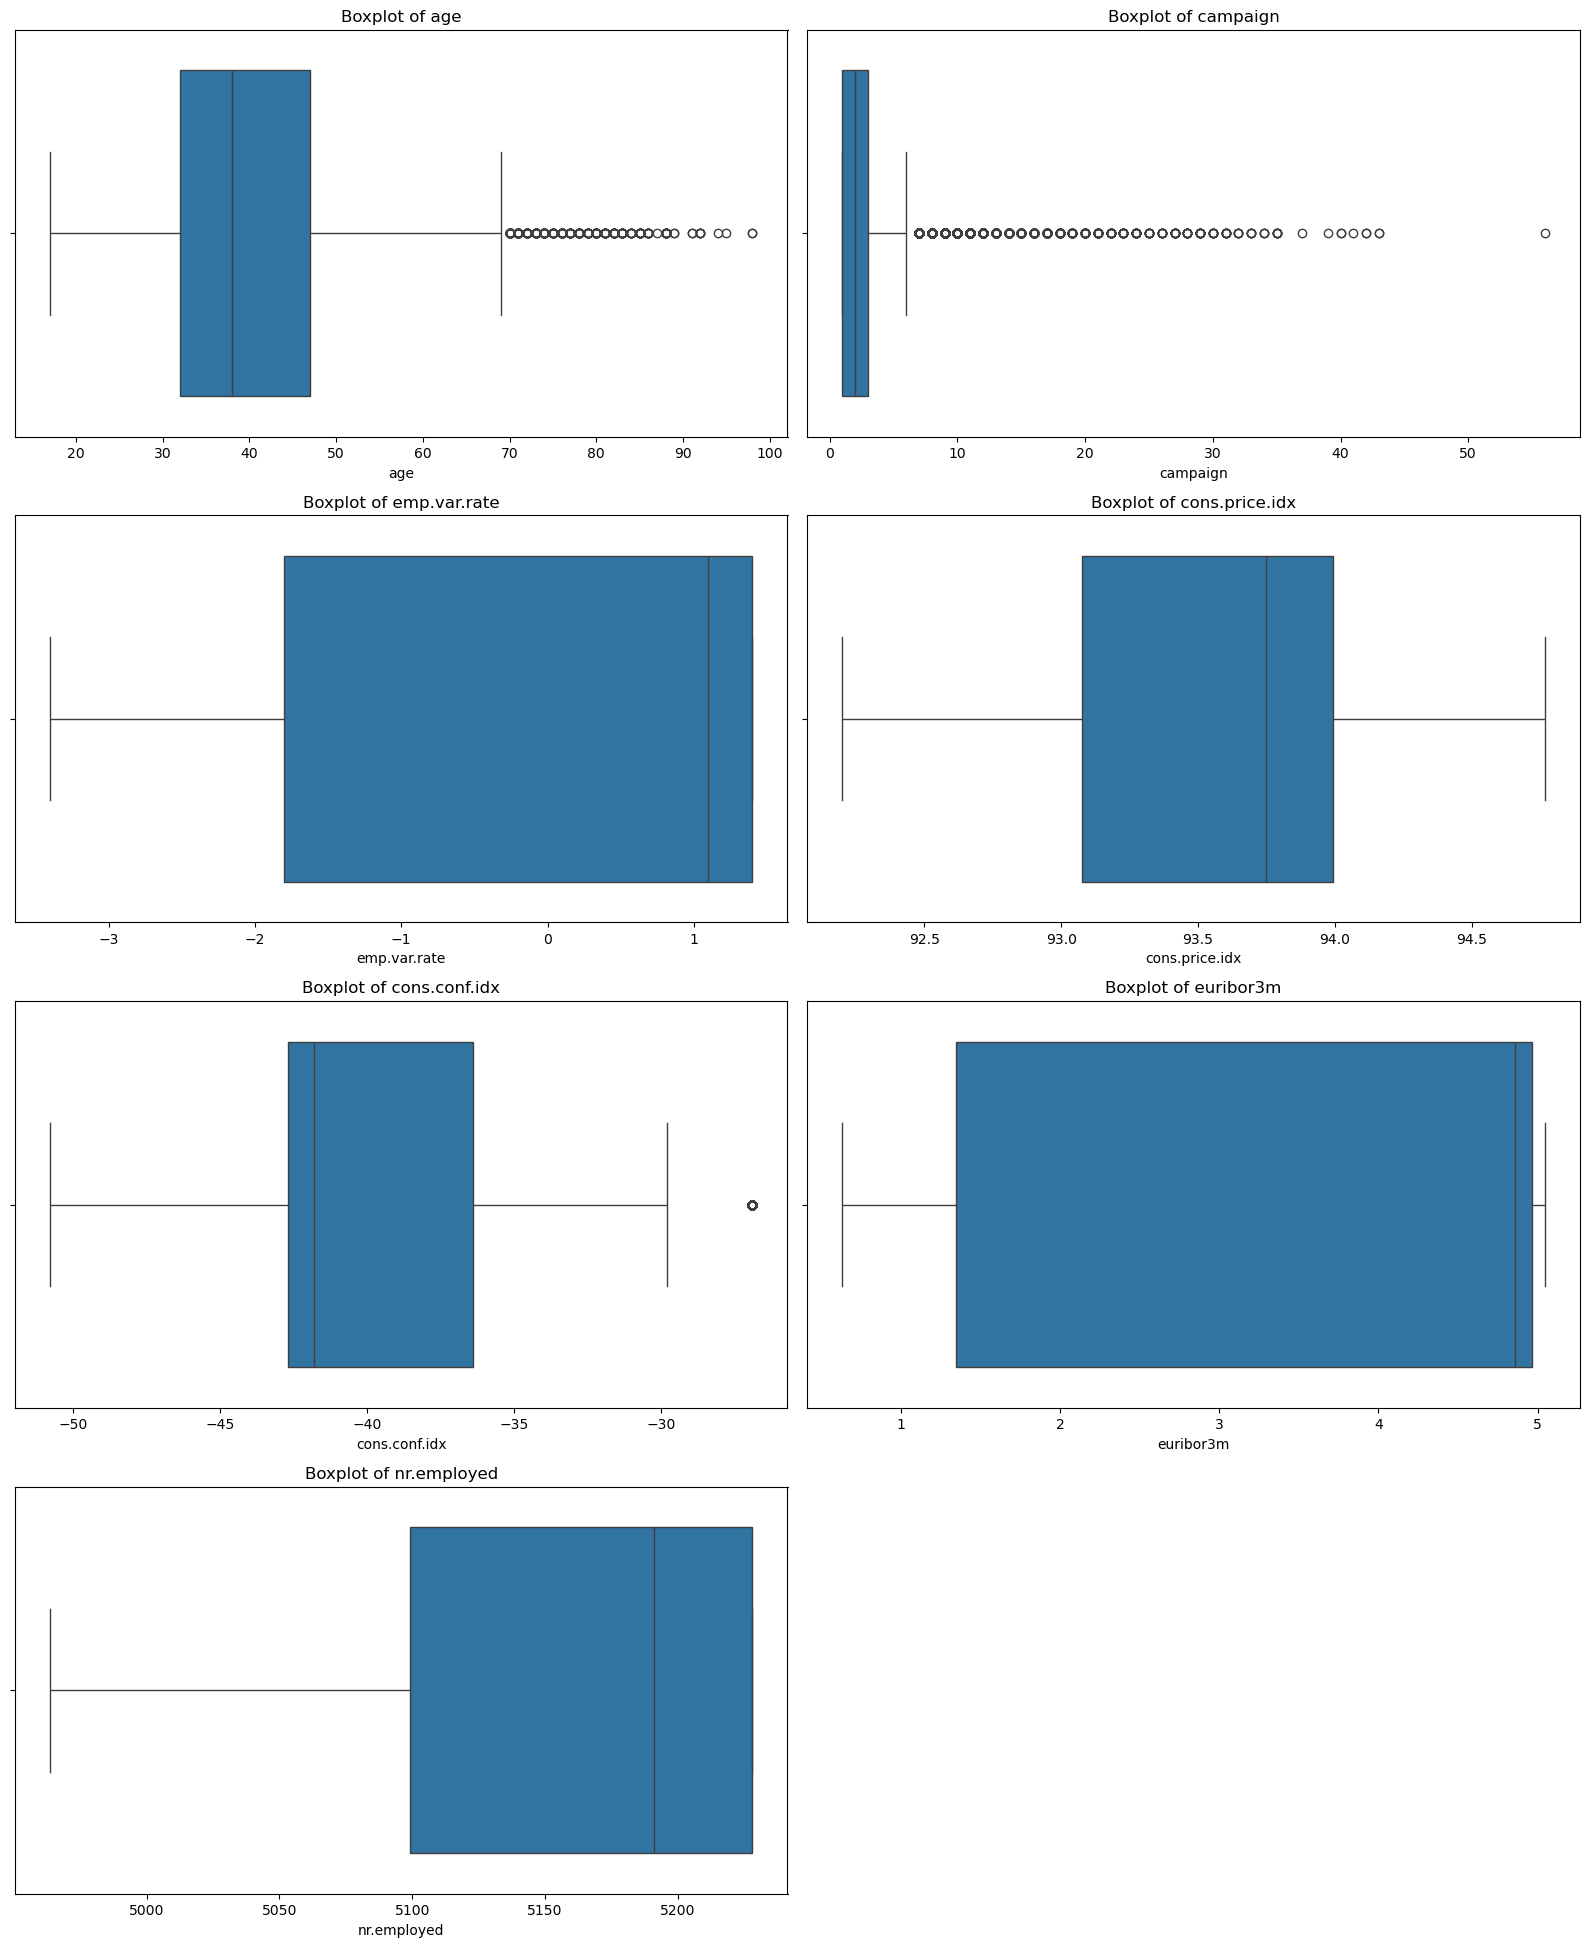

In [109]:
# List of important numeric columns for outlier detection
numeric_cols = ['age', 'campaign',  
                'emp.var.rate', 'cons.price.idx', 
                'cons.conf.idx', 'euribor3m', 'nr.employed']

# Create boxplots for each numeric column
plt.figure(figsize=(16, 24))  # Adjust figure size for better layout

for idx, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 2, idx)  # 5 rows, 2 columns layout
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()


**Avoiding 'duration' -** 

                    ->duration = the call duration (in seconds) during the last contact.
                    
                    ->Higher duration → much higher chance that the client subscribes.

                    ->It’s almost directly telling the model the outcome (whether the client said "yes" or "no").This creates a problem
                      called data leakage. 



 **Avoiding 'pdays' & 'Previous' while dealing with outliners beacuse they are discrete not continous**

# IQR

**1.Age**

In [114]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['age'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['age'].quantile(0.25)
Q3 = data['age'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 15.0
Minimum limit: 9.5
Maximum Limit: 69.5


In [115]:
# Impute outlier
data.loc[data['age'] > max_limit,'age']=data['age'].median()

In [116]:
# Filtering the data
data.loc[data['age'] > max_limit]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y


**2.campaign**

In [118]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['campaign'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['campaign'].quantile(0.25)
Q3 = data['campaign'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)


IQR: 2.0
Minimum limit: -2.0
Maximum Limit: 6.0


In [119]:
# Replace high outliers with median
data.loc[data['campaign'] > max_limit, 'campaign'] = data['campaign'].median()

# (Optional) Replace low outliers too — if they exist and are valid
data.loc[data['campaign'] < min_limit, 'campaign'] = data['campaign'].median()


In [120]:
# Filtering the data
data.loc[(data['campaign'] < min_limit) | (data['campaign'] > max_limit)]


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y


**3.emp.var.rate**

In [122]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['emp.var.rate'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['emp.var.rate'].quantile(0.25)
Q3 = data['emp.var.rate'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 3.2
Minimum limit: -6.6000000000000005
Maximum Limit: 6.200000000000001


In [123]:
# Filtering the data
data.loc[(data['emp.var.rate'] < min_limit) | (data['emp.var.rate'] > max_limit)]


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y


**4.cons.price.idx**

In [125]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['cons.price.idx'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['cons.price.idx'].quantile(0.25)
Q3 = data['cons.price.idx'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 0.9189999999999969
Minimum limit: 91.69650000000001
Maximum Limit: 95.3725


**5.cons.conf.idx**

In [127]:
# Use iqr range because some skewed in data
iqr = stats.iqr(data['cons.conf.idx'],interpolation='midpoint')
print("IQR:",iqr)

# Getting first & third quantile
Q1 = data['cons.conf.idx'].quantile(0.25)
Q3 = data['cons.conf.idx'].quantile(0.75)

# Get maximum and minimum limit
min_limit = Q1 - 1.5*iqr
print("Minimum limit:",min_limit)

max_limit = Q3 + 1.5*iqr
print("Maximum Limit:",max_limit)

IQR: 6.300000000000004
Minimum limit: -52.150000000000006
Maximum Limit: -26.949999999999992


In [128]:
# impute outlier
data.loc[data['cons.conf.idx'] > max_limit,'cons.conf.idx']=data['cons.conf.idx'].median()

In [129]:
# Filtering the data
data.loc[(data['cons.conf.idx'] < min_limit) | (data['cons.conf.idx'] > max_limit)]


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y


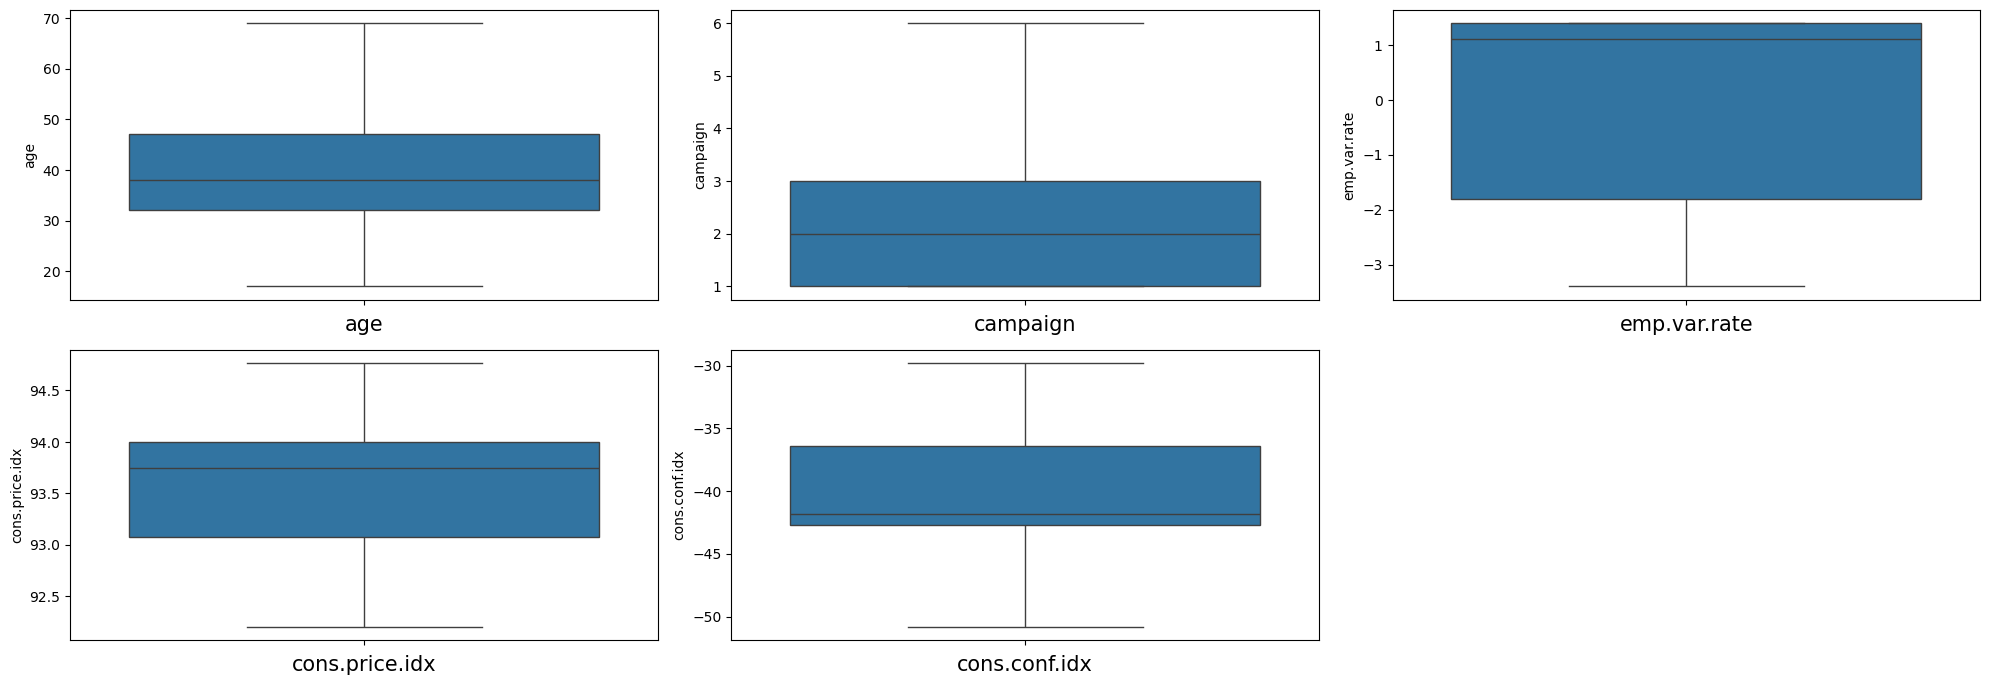

In [130]:
out = data[['age','campaign',
            'emp.var.rate','cons.price.idx','cons.conf.idx']]

plt.figure(figsize=(20,10))  # defining canvas size
plotno = 1  # counter

for column in out:  # iterating over columns
    if plotno <= 7:  # you have 7 plots to draw
        plt.subplot(3, 3, plotno)  # 3 rows, 3 columns (space for 9 plots)
        sns.boxplot(y=out[column])  # use 'y' instead of passing directly
        plt.xlabel(column, fontsize=15)  # x-axis label
    plotno += 1  # counter increment

plt.tight_layout()
plt.show()


**Outlier imputation was successful; no outliers are present in the dataset.**

### ENCODING CATEGORICAL DATA TO NUMERICAL DATA

In [133]:
from sklearn.preprocessing import LabelEncoder      # import Label Encoder to Convert Catregorical data to Numerical
le=LabelEncoder()                                   #Create a Label Encoder Variable

In [134]:
## Transfer Data From Categorical to Numerical by using Fit_transform method 
data['job']=le.fit_transform(data['job'])
data['marital']=le.fit_transform(data['marital'])
data['education']=le.fit_transform(data['education'])
data['default']=le.fit_transform(data['default'])
data['housing']=le.fit_transform(data['housing'])
data['loan']=le.fit_transform(data['loan'])
data['contact']=le.fit_transform(data['contact'])
data['month']=le.fit_transform(data['month'])
data['day_of_week']=le.fit_transform(data['day_of_week'])
data['poutcome']=le.fit_transform(data['poutcome'])
data['y']=le.fit_transform(data['y'])

In [135]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,261,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,149,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,226,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,151,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,307,1,0,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [136]:
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,38,5,1,5,0,1,0,0,7,0,334,1,0,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41184,46,1,1,5,0,0,0,0,7,0,383,1,0,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41185,56,5,1,6,0,1,0,0,7,0,189,2,0,0,1,-1.1,94.767,-50.8,1.028,4963.6,0
41186,44,9,1,5,0,0,0,0,7,0,442,1,0,0,1,-1.1,94.767,-50.8,1.028,4963.6,1
41187,38,5,1,5,0,1,0,0,7,0,239,3,0,1,0,-1.1,94.767,-50.8,1.028,4963.6,0


### SCALING NUMERICAL DATA

In [138]:
from sklearn.preprocessing import StandardScaler 

In [139]:
ss=StandardScaler()

In [140]:
data[['age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']]=ss.fit_transform(data[['age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']])

In [141]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,1.706581,3,1,0,0,0,0,1,6,1,0.010471,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.71246,0.33168,0
1,1.810519,7,1,3,0,0,0,1,6,1,-0.421501,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.71246,0.33168,0
2,-0.268244,7,1,3,0,1,0,1,6,1,-0.124520,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.71246,0.33168,0
3,0.043571,0,1,1,0,0,0,1,6,1,-0.413787,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.71246,0.33168,0
4,1.706581,7,1,3,0,0,1,1,6,1,0.187888,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.71246,0.33168,0


In [142]:
data.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,-0.164305,5,1,5,0,1,0,0,7,0,0.292025,-0.838424,-0.164012,-0.349494,1,-0.752343,2.058168,-2.300969,-1.495186,-2.815697,1
41184,0.667200,1,1,5,0,0,0,0,7,0,0.481012,-0.838424,-0.164012,-0.349494,1,-0.752343,2.058168,-2.300969,-1.495186,-2.815697,0
41185,1.706581,5,1,6,0,1,0,0,7,0,-0.267225,-0.033496,-0.164012,-0.349494,1,-0.752343,2.058168,-2.300969,-1.495186,-2.815697,0
41186,0.459323,9,1,5,0,0,0,0,7,0,0.708569,-0.838424,-0.164012,-0.349494,1,-0.752343,2.058168,-2.300969,-1.495186,-2.815697,1
41187,-0.164305,5,1,5,0,1,0,0,7,0,-0.074380,0.771432,-0.164012,1.671136,0,-0.752343,2.058168,-2.300969,-1.495186,-2.815697,0


### BALANCING DATA

#### Smote

In [145]:
# calculate the Target Class
data['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

**we can Clearly see that the Target Class is Not Balanced , so we do Data Balance By SMOTE method**

In [147]:
# Create X & Y Variable for SMOTE
X = data.drop('y',axis=1)
Y = data['y']

In [148]:
from imblearn.over_sampling import SMOTE                                # import SMOTE from oversampling
smote = SMOTE()                                                         # Make a variable for SMOTE
X_smot, y_smot = smote.fit_resample(X, Y)  

In [149]:
y_smot.value_counts()           

y
0    36548
1    36548
Name: count, dtype: int64

**Now Data class is Balanced**

In [151]:
# Create a data frame using Two SMOTE values
data= pd.concat([X_smot, y_smot],axis=1)

In [152]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,1.706581,3,1,0,0,0,0,1,6,1,0.010471,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.712460,0.331680,0
1,1.810519,7,1,3,0,0,0,1,6,1,-0.421501,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.712460,0.331680,0
2,-0.268244,7,1,3,0,1,0,1,6,1,-0.124520,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.712460,0.331680,0
3,0.043571,0,1,1,0,0,0,1,6,1,-0.413787,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.712460,0.331680,0
4,1.706581,7,1,3,0,0,1,1,6,1,0.187888,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.712460,0.331680,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73091,-0.654090,6,1,3,0,0,0,0,7,2,-0.020573,-0.838424,-0.164012,-0.349494,1,-0.115781,-0.649003,-0.303225,0.371815,0.398115,1
73092,-0.556912,9,1,5,0,0,0,0,1,0,2.682488,0.950681,-0.164012,-0.349494,1,0.839061,-0.227465,1.036172,0.774600,0.845170,1
73093,-1.188735,9,2,6,0,1,0,0,3,2,1.092696,-0.165027,-0.164012,-0.349494,1,0.839061,0.591424,-0.462136,0.771163,0.845170,1
73094,-0.169484,0,1,6,0,0,0,1,6,0,2.451164,-0.838424,-0.164012,-0.349494,1,0.648092,0.722722,0.968067,0.713631,0.331680,1


# Feature Selection

#### check correlation

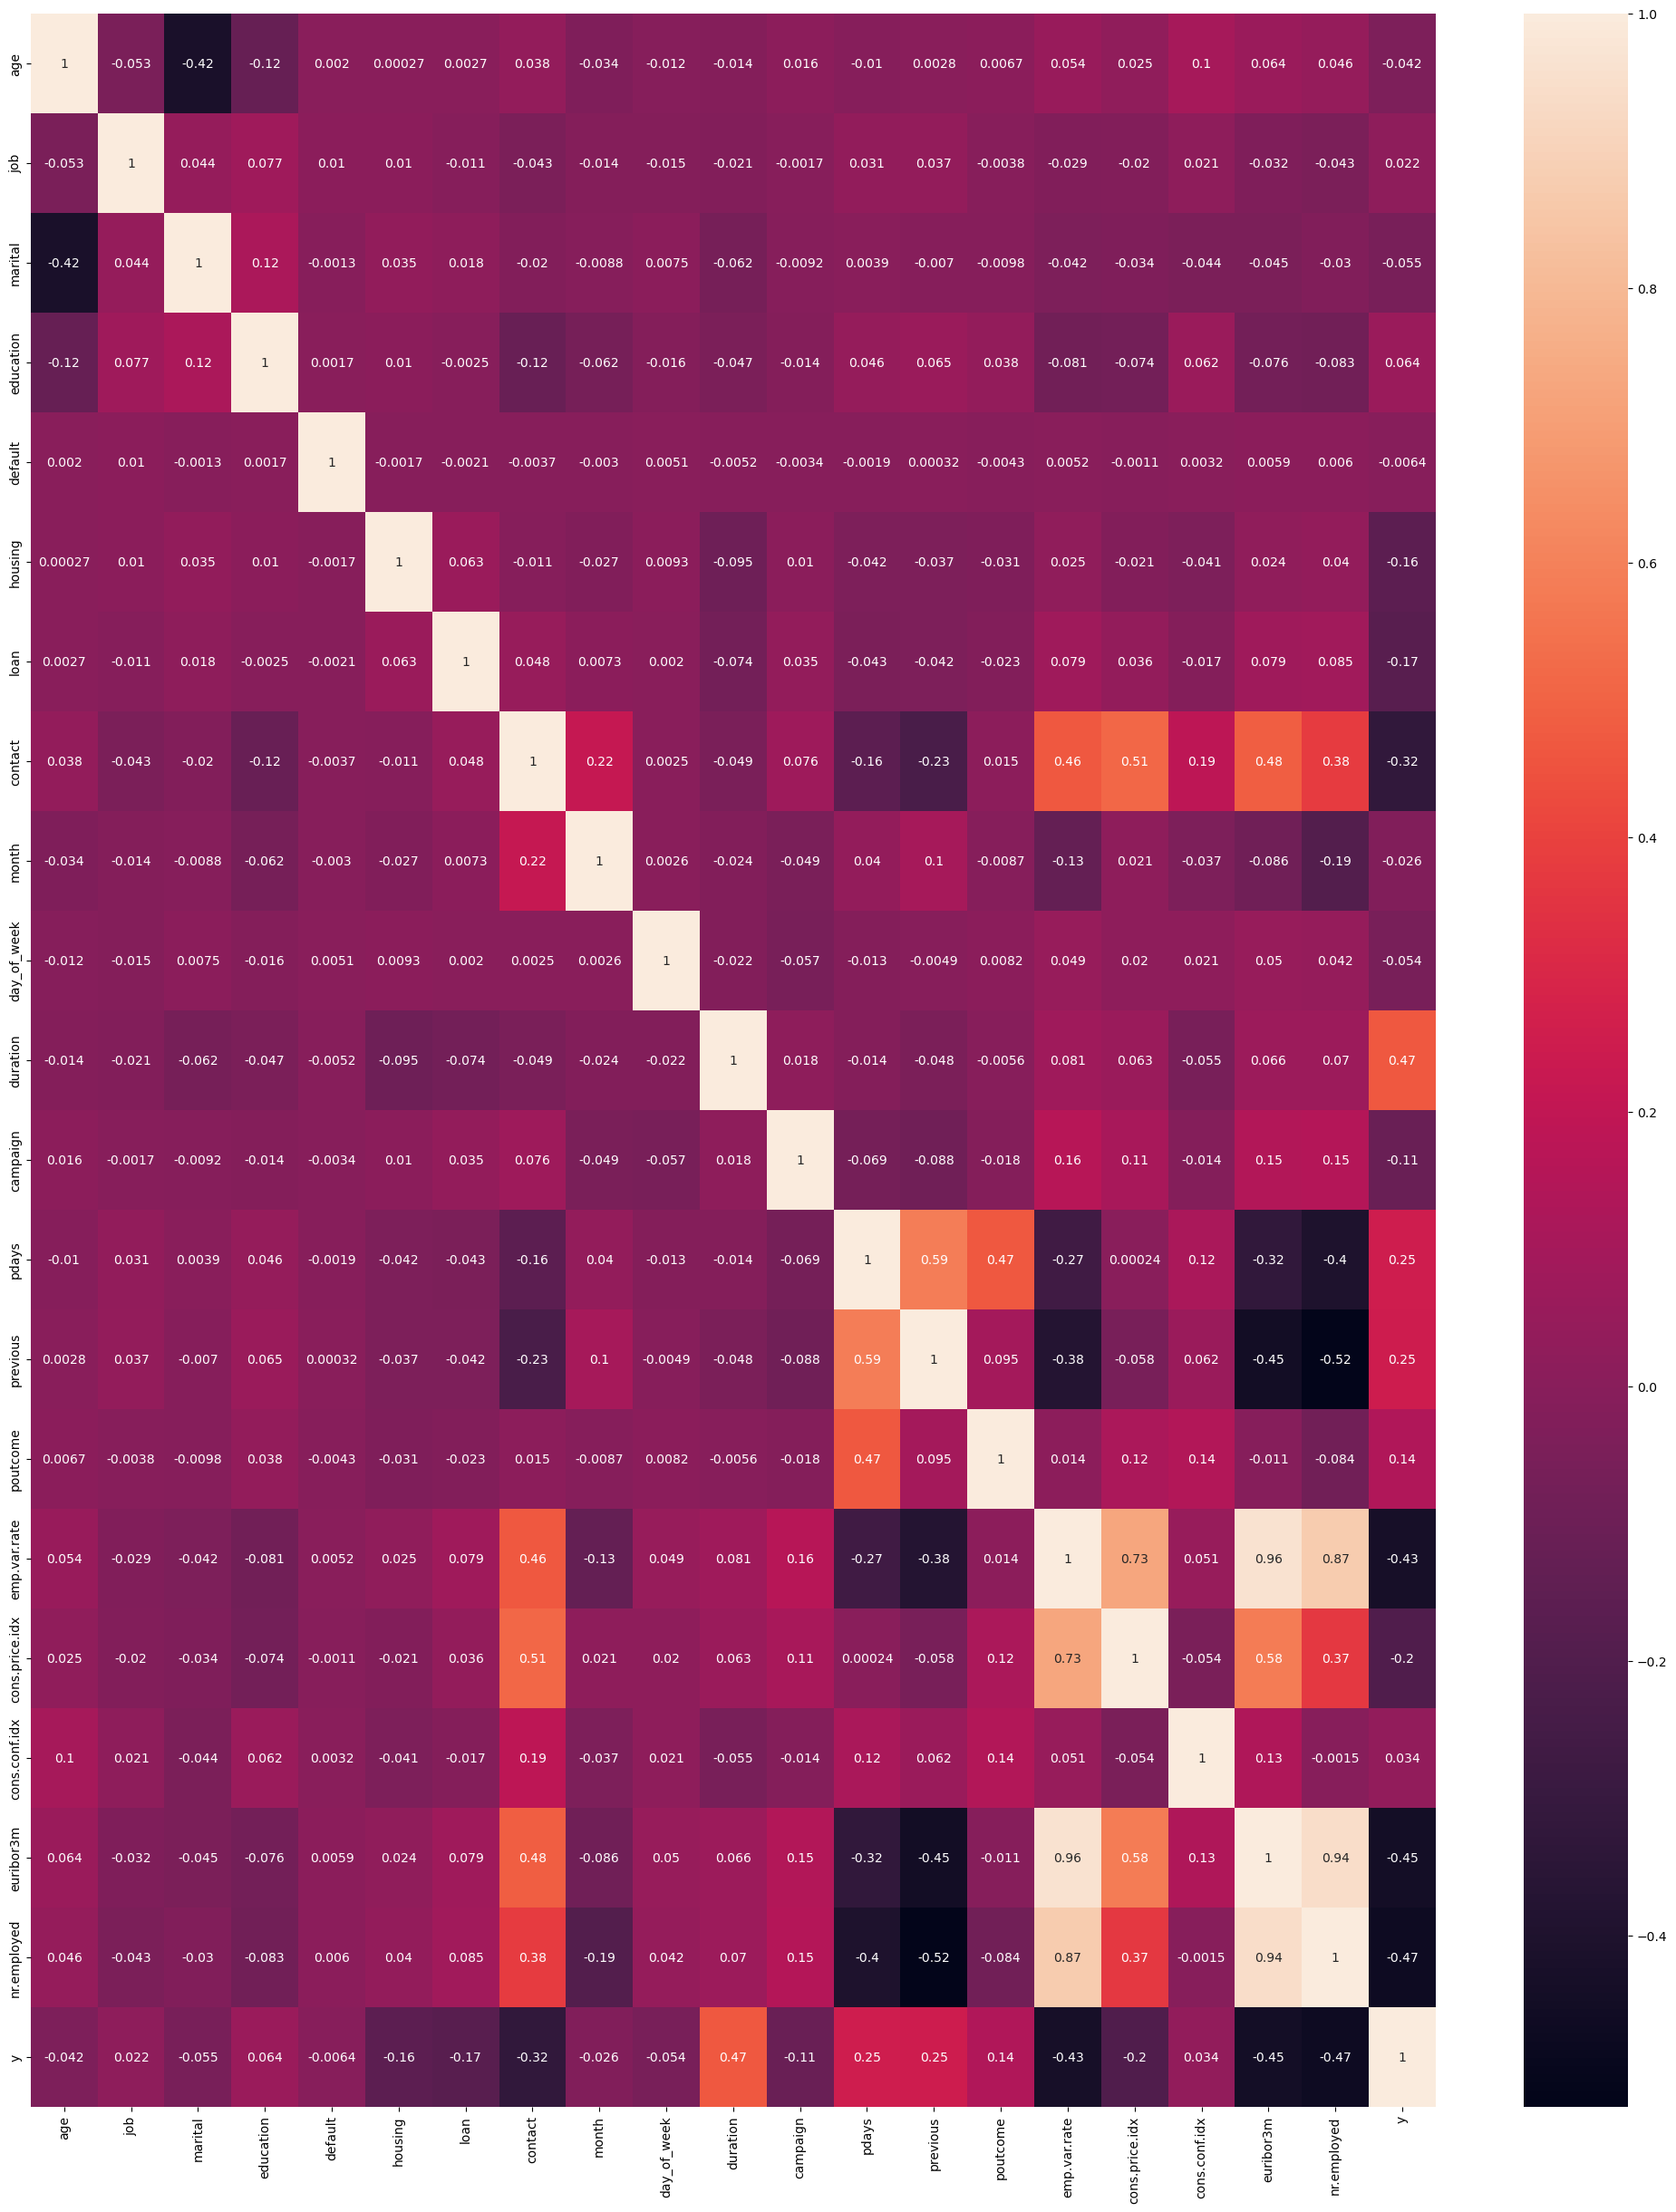

In [155]:
# check the co-relation between each variable and with target class.
plt.figure(figsize=(25,30))                                      # set the Canvas size
sns.heatmap(data.corr(),annot=True)                              # plot heat map for co-relation
plt.show()

###  found that  'emp.var.rate' , 'nr.employed'& 'euribor3m' are highly corelated with each other , 
### so we can remove anyt two of them.

In [156]:
data.duplicated().sum()

21

In [157]:
import numpy as np
# Create correlation matrix
corr_matrix = data.corr().abs()
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
 
# Find features with correlation greater than 0.85
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print("Highly correlated features to consider dropping:", to_drop)


Highly correlated features to consider dropping: ['euribor3m', 'nr.employed']


### Creating X and Y

In [159]:
# create dependent and independent variable
X = data.drop(['y','euribor3m','nr.employed'],axis=1)    # Independent Variable
y = data['y']                                            # Dependent variable

In [160]:
y.value_counts()

y
0    36548
1    36548
Name: count, dtype: int64

# MODEL CREATION AND EVALUTION

In [162]:
# split the data into train & test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=15)

# import Required metrics to see the performance
from sklearn.metrics import accuracy_score,classification_report,f1_score,precision_score,recall_score

## (i) LOGISTIC REGRESSION

In [164]:
# create Linear Model
from sklearn.linear_model import LogisticRegression        # import Logistic regression from Linear model
log= LogisticRegression(random_state=15)                                 # Create a variable of Logistic regression
log.fit(x_train,y_train)                                   # Fit the Model into train data
y_pred = log.predict(x_test)                             # Predict the x_test values as y_pr_log

In [165]:
y_pred

array([0, 1, 0, ..., 0, 0, 1])

#### MODEL EVALUTION

In [167]:
acc_log = accuracy_score(y_test,y_pred)                  # Calculate Accuracy Score testing
acc_log

0.8735464453463451

In [168]:
# print Accuracy Score for Training Data
y_pr_log_train=log.predict(x_train)
acc_lr_train = accuracy_score(y_train,y_pr_log_train)
acc_lr_train

0.8742548908476167

In [169]:
print(classification_report(y_test,y_pred))       # classification report

              precision    recall  f1-score   support

           0       0.88      0.86      0.87     10971
           1       0.86      0.89      0.88     10958

    accuracy                           0.87     21929
   macro avg       0.87      0.87      0.87     21929
weighted avg       0.87      0.87      0.87     21929



In [170]:
print("Precission Score : " ,precision_score(y_test,y_pred))
print("recall_score : " ,recall_score(y_test,y_pred))
print("f1_score : " ,f1_score(y_test,y_pred))

Precission Score :  0.8636807962321159
recall_score :  0.8869319218835554
f1_score :  0.8751519517356265


## (ii)  K - NEAREST NEIGHBOUR ( KNN )

#### MODEL CREATION

In [173]:
from sklearn.neighbors import KNeighborsClassifier                 # from scikit-learn import KNeighborsClassifier

## taking optimal k to determine how many nearest neighbors  to create

# create a list to store the error values for each k
error_rate = []
for i in range(1,11):                             # start of loop from 1 to 10
    knn = KNeighborsClassifier(n_neighbors=i)     # object creation
    knn.fit(x_train,y_train)                  # x_train for distance   And y_train used for getting estimate from neighbour
    pred_i = knn.predict(x_test)                  # obtain estimates for i neighbours
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

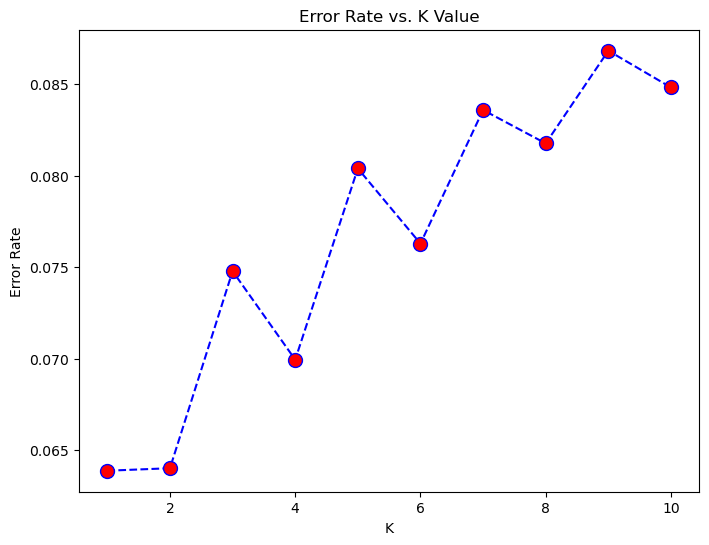

In [174]:
 #Lets plot the k-value and error rate

plt.figure(figsize=(8,6))
plt.plot(range(1,11),error_rate,color='blue', linestyle='dashed', 
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [175]:
from sklearn.neighbors import KNeighborsClassifier    # import KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)             # Create a Variable of KNN
knn.fit(x_train,y_train)                              # fit model on Training Data
y_pred_knn = knn.predict(x_test)                        # predict the x_test

#### MODEL EVALUTION

In [177]:
acc_knn = accuracy_score(y_test,y_pred_knn)             # Calculate Accuracy for testing data
acc_knn

0.9196041771170596

In [178]:
# print Accuracy Score for Training Data
y_pred_train=knn.predict(x_train)
acc_knn_train = accuracy_score(y_train,y_pred_train)
acc_knn_train

0.9399222154904529

#### HYPERPARAMETER OPTIMIZATION

In [180]:
from sklearn.model_selection import GridSearchCV    # import Grid Search cv from Sklearn.model_selection

# Hyperparameter Tuning defining
hyperpara = [{'n_neighbors':[2,3,4,5,6,7,8,9,10],'weights':['distance','uniform']}]   # define n_neighbors & weights values
grid = GridSearchCV(estimator = KNeighborsClassifier(),param_grid = hyperpara,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)                     # fit the model

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10],
                          'weights': ['distance', 'uniform']}],
             scoring='accuracy')

In [181]:
grid.best_params_

{'n_neighbors': 2, 'weights': 'distance'}

In [182]:
Knn_smote = KNeighborsClassifier(n_neighbors=5,weights="distance")    # make a variable for KNeighborsClassifier
Knn_smote.fit(x_train,y_train)                            # fit the model
Y_prd_knn_hyp = grid.predict(x_test)
acc_knn_hyp = accuracy_score(y_test,Y_prd_knn_hyp)   # finding accuracy
acc_knn_hyp

0.9361119978111176

## (iii) SUPPORT VECTOR CLASSIFIER

#### MODEL CREATION

In [185]:
from sklearn.svm import SVC                     # import Support vector Classifier
svm = SVC(random_state=42)                      # Create a variable of support Vector
svm.fit(x_train,y_train)                        # fit suppoprt vector on yraining Data
y_pr_svm = svm.predict(x_test)                  # Predict x_test

#### MODEL EVALUTION

In [187]:
acc_svm = accuracy_score(y_test,y_pr_svm)       # Calculate Accuracy testing
acc_svm

0.8908750969036435

In [188]:
# print Accuracy Score for Training Data
y_pred_train=knn.predict(x_train)
acc_svm_train = accuracy_score(y_train,y_pred_train)
acc_svm_train

0.9399222154904529

#### HYPERPARAMETER TUNING

In [270]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

# Reduced and smarter parameter space
param_dist = {
    'C': [0.1, 1, 10],
    'gamma': [0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

# Random Search
svm_random = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_dist,
    n_iter=6,        # Only 6 random combinations
    cv=2,            # 2-fold CV
    verbose=3,
    scoring='accuracy',
    n_jobs=-1
)

svm_random.fit(x_train, y_train)


Fitting 2 folds for each of 6 candidates, totalling 12 fits


RandomizedSearchCV(cv=2, estimator=SVC(random_state=42), n_iter=6, n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10], 'gamma': [0.1, 0.01],
                                        'kernel': ['rbf', 'linear']},
                   scoring='accuracy', verbose=3)

In [272]:
# print best parameter after tuning
print(svm_random.best_params_)

# print how our model looks after hyper-parameter tuning
print(svm_random.best_estimator_)


{'kernel': 'rbf', 'gamma': 0.1, 'C': 10}
SVC(C=10, gamma=0.1, random_state=42)


In [276]:
svm_hyp =SVC(C=10, gamma=0.1,random_state=42,kernel='rbf')   # Create a variable of support Vector
svm_hyp.fit(x_train,y_train)                        # fit suppoprt vector on yraining Data
y_hyp_svm = svm_hyp.predict(x_test)                  # Predict x_test
acc_hyp_svm = accuracy_score(y_test,y_hyp_svm)       # Calculate Accuracy
acc_hyp_svm

0.9392129144055816

## (iv) DECISION TREE

In [279]:
from sklearn.tree import DecisionTreeClassifier              # import Decision tree classifier            
d_tree = DecisionTreeClassifier(random_state=42)             # Make a variable of decision tree
d_tree.fit(x_train,y_train)                                  # Fit the decision tree model on training data

y_pr_dtree = d_tree.predict(x_test)                          #  Predict x_test

0.9055588490127229

#### MODEL EVALUTION

In [281]:
acc_dtree = accuracy_score(y_test,y_pr_dtree)                # Check Model performance
acc_dtree

0.9055588490127229

### HYPERPARAMETERTUNNING FOR DECISION TREE

In [285]:
from sklearn.model_selection import RandomizedSearchCV  # import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Creating dictionary of hyperparameters for randomized search
params = {
    "criterion": ["gini", "entropy"],    # quality of split
    "splitter": ["best", "random"],      # searches the features for a split
    "max_depth": list(range(1, 20)),      # depth of tree from 1 to 19
    "min_samples_split": [2, 3, 4],       # minimum samples required to split internal node
    "min_samples_leaf": list(range(1, 20)), # minimum samples required at a leaf node
}

# Create the Decision Tree model
tree = DecisionTreeClassifier(random_state=4)

# Setup RandomizedSearchCV instead of GridSearchCV
tree_cv = RandomizedSearchCV(tree, params, n_iter=50, scoring="accuracy", n_jobs=-1, verbose=1, cv=3, random_state=42)

# Fit the model
tree_cv.fit(x_train, y_train)

# Get the best parameters
best_params = tree_cv.best_params_

# Print the best parameters
print(f"Best parameters: {best_params}")


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters: {'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 12, 'criterion': 'gini'}


In [287]:
tree_cv.best_score_

0.9045088245475176

In [291]:
tree_cv.best_estimator_


DecisionTreeClassifier(max_depth=12, min_samples_leaf=4, random_state=4)

In [293]:
#passing best parameter to decision tree
dtree_hyp=DecisionTreeClassifier(criterion='entropy',max_depth=12,min_samples_leaf= 4,min_samples_split=2,splitter='best',random_state=4)
dtree_hyp.fit(x_train,y_train)                           #traing model with best parameter
y_hyp_tree=dtree_hyp.predict(x_test)                     #predicting
acc_hyp_tree=accuracy_score(y_test,y_hyp_tree)           #checking accuracy
acc_hyp_tree

0.9039627890008665

# MODEL COMPARISION REPORT

In [308]:
Results = pd.DataFrame({'model':['Log_Regression','K_nearest','Support vector','Decision tree'],
                        
                        'Test Accuracy':[acc_log,acc_knn,acc_svm,acc_dtree],
                        
                        'HyperParameter':['not available',acc_knn_hyp,acc_hyp_svm,acc_hyp_tree,
                               ],
              
              'F1  score':[f1_score(y_test,y_pred),f1_score(y_test,y_pred_knn),f1_score(y_test,y_pr_svm),
                          f1_score(y_test,y_pr_dtree)]
             })

In [312]:
Results

,model,Test Accuracy,HyperParameter,F1 score
0,Log_Regression,0.873546,not available,0.875152
1,K_nearest,0.919604,0.936112,0.924565
2,Support vector,0.890875,0.939213,0.895907
3,Decision tree,0.905559,0.903963,0.906438


- **K-Nearest Neighbors (KNN) has the highest test accuracy of 91.96%.**
- **This means KNN is the most accurate model.**
- **K-Nearest Neighbors (KNN) also has the highest F1 Score at 92.45%, meaning it has a good balance between precision and recall.**    
- **KNN's hyperparameter 93.61% further adds confidence in its effectiveness.**


**CONSIDERING ALL THESE POINTS I AM PREFERING K_NEAREST_NEIGHBOUR ALGORITHM**

# Challenges Faced in the Data


**1.Presence of Unknown or Missing Values -**

    - Several columns like job, education, default, housing, and loan had "unknown" values.
    
    - For variables like education, replacing 'unknown' with mode (most frequent category).

**2.High Correlation with Target Variable (Data Leakage)-**

    - Problem: Variables like duration had a very high correlation with the outcome (y), but it’s not realistic for prediction (known 
      only after the call).
    
    - Dropped duration from model training to avoid data leakage and ensure a realistic predictive setup.
    
    - Highly correlated features to consider dropping: ['euribor3m', 'nr.employed'].So ignored.

**3.Categorical Variables Handling -**

    - Problem: Many categorical features like job, marital, education, poutcome, etc.
    
    - Technique Used: Label Encoding.


                                                                    




# Suggestions to the Bank Marketing Team

**1.Target Specific Customer Groups :**

     -> Focus more on retired, students, and entrepreneurs, as these groups had a higher probability of subscribing.

     -> Customers with a "university degree" or professional courses background are more likely to purchase.


**2.Optimize Contact Timing:**

    -> Customers contacted in the months of March, April, September, and October showed higher subscription rates.

    -> Prefer contacting customers on Tuesdays and Thursdays, where positive responses were higher.

**3.Personalize Offers Based on Financial Behavior :**

     -> lients who do not have housing or personal loans tend to subscribe more.

     -> Offer customized term deposits focusing on investment benefits rather than debt clearance.
 

**4.Minimize Number of Contacts :**

    ->The more the customer is contacted during a campaign, the less likely they are to subscribe.

    ->Design effective and short campaigns, ensuring that customers are not overwhelmed.

**5.Economic Environment Matters :**

    ->Pay attention to the employment variation rate and consumer confidence index — when the economic indicators are positive, 
      campaigns should be more aggressive. 

**6.Preferred Communication Mode :**

    ->Cellular contact performed better than telephone.

    -> Focus campaigns more via mobile communication rather than landline calls.

**7.Consider Economic Indicators :**

    ->Launch campaigns aggressively during periods of positive employment variation and consumer confidence.